# **🌍 GeoPython Marathon：** From Basics to Deep Learning for Geoscientists

- **📅 课程名称**：GeoPython102：常用库函数
- **👨‍🏫 分享人**：于峻川
- **📅 课程时间**：2025年 8 月8 日

- > 🐍课程资源：ftp://172.25.13.69/aitech/AITechWorkshop/
   

[<img src="./image/封面.jpg" width="700">]()

### 🎯**1. 基础库: os、sys、datatime、glob** 

- > 💡库函数安装方法：以matplotlib为例，在cell中输入!pip install matplotlib  （大部分常用库函数在conda环境中已有无需安装）安装后运行一下代码，未报错即表示该环境下已配置完成


In [89]:
import os,sys,glob,tqdm,argparse
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

#### 1.1 Os库函数


os库函数提供了非常多的与操作系统交互的函数，可以归纳为操作目录和文件两类。

目录相关操作

In [90]:
import os
# 显示当前工作目录
current_dir = os.getcwd()
print("当前工作目录:" +current_dir)

当前工作目录:k:\BootCamp\Studio\AI Learning\Python for Earth Science Marathon\Lesson-3


In [91]:
# 将工作目录修改为c:\\test
new_dir = "C:\\test" 
os.chdir(new_dir)
print(os.getcwd())

C:\test


In [92]:
# 默认目录修改为原工作目录，重启kernel工作目录会重置为程序所在目录
os.chdir(current_dir)
print(os.getcwd())


k:\BootCamp\Studio\AI Learning\Python for Earth Science Marathon\Lesson-3


In [93]:
# 检查目录是否存在
if not os.path.exists('data'):
    os.makedirs('data') #不存在就新建目录
# 删除新建目录
os.rmdir('data')


In [94]:
# 查看当前目录中的文件
contents = os.listdir()
print("目录内容:")
print(contents)
# 确定是文件还是文件夹
for item in contents:
    if os.path.isfile(item):
        print(f"{item} 是文件")
    elif os.path.isdir(item):
        print(f"{item} 是目录")
    else:
        print(f"{item} 未知类型")


目录内容:
['crops', 'data1.npy', 'image', 'Indian_pines.csv', 'Lesson-3.ipynb', 'multi_data.npz', 'NDVI.csv', 'test.py', 'testdata.csv']
crops 是目录
data1.npy 是文件
image 是目录
Indian_pines.csv 是文件
Lesson-3.ipynb 是文件
multi_data.npz 是文件
NDVI.csv 是文件
test.py 是文件
testdata.csv 是文件


In [95]:
# 目录遍历
for root, dirs, files in os.walk("."):
    print(f"当前目录: {root}")
    print(f"子目录: {dirs}")
    print(f"文件: {files}")
    print("-" * 40)

当前目录: .
子目录: ['crops', 'image']
文件: ['data1.npy', 'Indian_pines.csv', 'Lesson-3.ipynb', 'multi_data.npz', 'NDVI.csv', 'test.py', 'testdata.csv']
----------------------------------------
当前目录: .\crops
子目录: []
文件: ['img_2003-03-03.jpg', 'img_2003-03-12.jpg', 'img_2003-04-15.jpg', 'img_2004-04-11.jpg', 'img_2006-03-01.jpg', 'img_2006-03-05.jpg', 'img_2006-04-24.jpg', 'img_2007-04-06.jpg', 'img_2008-04-16.jpg', 'img_2011-03-03.jpg', 'img_2012-04-09.jpg', 'img_2013-04-13.jpg', 'img_2014-03-24.jpg', 'img_2015-04-01.jpg', 'img_2016-04-18.jpg', 'img_2017-03-17.jpg', 'img_2017-04-13.jpg', 'img_2018-03-04.jpg', 'img_2019-04-22.jpg', 'img_2020-03-15.jpg', 'img_2022-04-07.jpg', 'img_2024-03-02.jpg', 'img_2024-03-20.jpg', 'img_2025-03-23.jpg', 'img_2025-04-18.jpg']
----------------------------------------
当前目录: .\image
子目录: []
文件: ['封面.jpg']
----------------------------------------


文件相关操作

In [96]:
# 创建一个新文件
with open("test.txt", "w") as file:
    file.write("这是一个测试文件")
# 修改文件名
os.rename("test.txt", "new_test.txt")
# 删除文件
# os.remove("new_test.txt")


In [97]:
# 文件路径拆分
filepath=os.path.abspath("new_test.txt")
dirname, filename = os.path.split(filepath)
print(f"目录部分: {dirname}")
print(f"文件名部分: {filename}")
# 定义新的输出路径
outpath='c:/'
outfile=os.path.join(outpath,filename)
print(f"新的输出路径: {outfile}")


目录部分: k:\BootCamp\Studio\AI Learning\Python for Earth Science Marathon\Lesson-3
文件名部分: new_test.txt
新的输出路径: c:/new_test.txt


#### 1.2 Sys库函数

sys库提供了访问与 Python 编译器紧密相关的变量和函数，常用功能是获取程序外部参数。

In [98]:
import sys

print(f"Python 版本信息：{sys.version}")


Python 版本信息：3.8.13 (default, Mar 28 2022, 06:59:08) [MSC v.1916 64 bit (AMD64)]


In [99]:
%%writefile test.py 
# 用writefile命令创建一个测试py文件，以下是py文件的具体内容

import sys

# 功能函数-计算两个数的乘积
def multiply(a, b):
    return float(a) * float(b)

# py主程序
def main():
    num1, num2 = sys.argv[1], sys.argv[2] # 解析py接收到的2个参数
    print("py接收的2个参数分别为：",num1,num2)
    result = multiply(num1, num2)
    print(result)
    
# 调用py执行main函数        
main()


Overwriting test.py


In [100]:
!python test.py 2 3
# os.popen("python test.py 2 3").read()



py接收的2个参数分别为： 2 3
6.0


#### 1.3 datetime库函数

datatime库可以表示和操作日期和时间，并支持格式化和解析日期和时间。

In [101]:
# 时间获取
from datetime import datetime, date,timezone

# 获取当前时间
now = datetime.now() 
today = date.today()  #
current_time = datetime.now().time()  

print("当前完整时间:", now)
print("当前日期:", today)
print("当前时间:", current_time)

当前完整时间: 2025-08-08 13:08:27.397130
当前日期: 2025-08-08
当前时间: 13:08:27.397130


In [102]:
# 拆解时间成分
year = now.year        
month = now.month      
day = now.day          
hour = now.hour        
minute = now.minute    
second = now.second    

print(f"日期拆解: {year}年{month}月{day}日")
print(f"时间拆解: {hour}时{minute}分{second}秒")

日期拆解: 2025年8月8日
时间拆解: 13时8分27秒


In [103]:
# 时间格式化
formatted = now.strftime("%Y-%m-%d %H:%M:%S")  # "年-月-日 时:分:秒"
custom_format = now.strftime("%B, %d, %Y")  # "月， 日, 年"
file_tag = now.strftime("%Y%m%d_%H%M%S")  # 年月日_时分秒

print("标准格式:", formatted)
print("自定义格式:", custom_format)
print("文件标签:", file_tag)

outfile=file_tag+"_result.txt"
print(outfile)



标准格式: 2025-08-08 13:08:27
自定义格式: August, 08, 2025
文件标签: 20250808_130827
20250808_130827_result.txt


In [104]:
local_time = datetime.now()  # 本地时间
utc_now=datetime.now(timezone.utc) # 转换为UTC时间

utc_time = utc_now.strftime("%Y-%m-%d %H:%M:%S %Z")
# utc_time = local_time.astimezone(pytz.utc)  # 也可以利用pytz函数转换为UTC
print("本地时间:", local_time)
print("UTC时间:", utc_time)

本地时间: 2025-08-08 13:08:27.443056
UTC时间: 2025-08-08 05:08:27 UTC


#### 1.4 glob库函数

是 Python 的标准库模块，用于基于 Unix 风格通配符（如 `*`、`?`、`[]`）进行文件路径的匹配和查找，支持递归搜索和跨平台操作。

创建演示文件夹

In [105]:
import glob

# 搜索特定目录下的特定格式文件
folder='./'
filelist=glob.glob(folder+'*.csv')
print(filelist,len(filelist))



['.\\Indian_pines.csv', '.\\NDVI.csv', '.\\testdata.csv'] 3


In [106]:
#  高级模式匹配
filelist=glob.glob("./crops/img_200?-[0-5]*.jpg")
newlist=[]
for file in filelist:
    newlist.append(file.split("\\")[-1])
print(newlist)

['img_2003-03-03.jpg', 'img_2003-03-12.jpg', 'img_2003-04-15.jpg', 'img_2004-04-11.jpg', 'img_2006-03-01.jpg', 'img_2006-03-05.jpg', 'img_2006-04-24.jpg', 'img_2007-04-06.jpg', 'img_2008-04-16.jpg']


### 💻**2. 数据分析库：Numpy、pandas** 

#### 2.1 Numpy库函数

Numpy是Python进行科学计算的基础库，提供了大量的函数和方法，用于数组的创建、索引与切片、数学运算、统计运算等操作。

##### 2.1.1 数组的创建方法

In [107]:
import numpy as np
# 从列表转换：np.array()
list_data = [1, 2, 3, 4]
arr = np.array(list_data)
print(arr)  

[1 2 3 4]


In [108]:
# 生成固定范围数据：np.arange()、np.linspace()
arr_arange = np.arange(0, 10, 2)  # 从0到10，步长为2
print(arr_arange)

[0 2 4 6 8]


In [109]:
# 生成等间隔数据: np.linspace
arr_linspace = np.linspace(0, 1, 5)  # 从0到1，生成5个数据点
print(arr_linspace)

[0.   0.25 0.5  0.75 1.  ]


In [110]:
# 生成随机数据：np.random模块
rand_uniform = np.random.rand(3, 2)  # 3行2列，取值[0,1)
print(rand_uniform)

[[0.62832898 0.92742194]
 [0.68099171 0.57741642]
 [0.61308925 0.9465605 ]]


##### 2.1.2 数组的属性查询

In [111]:
# 维度（ndim）：数组的维数。
arr1d = np.array([1, 2, 3])
arr2d = np.array([[1, 2], [3, 4]])
print(f"一维数组维度：{arr1d.ndim}")  # 输出：1
print(f"二维数组维度：{arr2d.ndim}")  # 输出：2

一维数组维度：1
二维数组维度：2


In [112]:
# 形状（shape）：各维度的大小。
size=rand_uniform.shape #3行2列
print(size)

(3, 2)


In [113]:
# 数据类型（dtype）：数组中元素的数据类型。
int_arr = np.array([1, 2, 3], dtype=np.int32)
float_arr = np.array([1.1, 2.2, 3.3], dtype=np.float64)
print(f"整数数组类型：{int_arr.dtype}")  # 输出：int32
print(f"浮点数数组类型：{float_arr.dtype}")  # 输出：float64

整数数组类型：int32
浮点数数组类型：float64


##### 2.1.3 数组的索引、切片和排序

In [114]:
# 一维数组索引：与列表索引类似。
arr = np.array([10, 20, 30, 40, 50])
print(arr[2])  # 输出：30（取索是从0开始计算）
print(arr[1:4])  # 输出：[20 30 40]（取索引1到3的元素）

# 二维数组索引：arr[row, col]
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(arr2d[1, 2])  # 输出：6（取第2行第3列元素）
print(arr2d[0:2, 1:3])  # 输出：[[2 3][5 6]]（取前2行，第2-3列元素）

30
[20 30 40]
6
[[2 3]
 [5 6]]


In [115]:
# 根据条件筛选元素
arr = np.array([1, 2, 3, 4, 5, 6])
mask = arr >= 3  # 生成布尔掩码
print(mask)  # 输出：[False False False  True  True  True]
print(arr[mask])  # 输出：[4 5 6]（筛选出大于3的元素）

[False False  True  True  True  True]
[3 4 5 6]


In [116]:
# 条件替换（np.where）
index = np.where(arr >= 5)  # 满足条件设为0
arr[index]=0
print(index,arr)
newarr=np.where(arr >= 0, arr * 10, arr) # 条件满足则乘10，否则原值
print(newarr)



(array([4, 5], dtype=int64),) [1 2 3 4 0 0]
[10 20 30 40  0  0]


In [117]:
# index索引：通过整数数组选取特定元素。
arr = np.array([10, 20, 30, 40, 50])
indices = [0, 2, 4]
print(arr[indices])  # 输出：[10 30 50]（取索引0、2、4的元素）

[10 30 50]


In [118]:
# 判断元素是否存在
print(np.any(arr > 20))
print(np.all(arr < 10))

True
False


In [119]:
# 排序
arr=np.random.randint(0,100,size=(10))
print( np.sort(arr)) # 默认升序排序
print( -np.sort(-arr)) # 降序排序

#  获取最大最小值
print( np.max(arr)) # 最大值
print( np.min(arr)) # 最小值


[ 4 21 47 48 56 64 70 74 81 86]
[86 81 74 70 64 56 48 47 21  4]
86
4


##### 2.1.3 数组形状调整

In [120]:
# flatten 与 ravel：将多维数组展平。
arr2d = np.array([[1, 2], [3, 4], [5, 6]])
print(arr2d)
print(arr2d.flatten())  # 输出：[1 2 3 4]
print(arr2d.ravel())  # 输出：[1 2 3 4]

# reshape：改变数组形状，不改变数据。
arr_reshaped = arr2d.reshape(3, 2)  # 转换为3行4列
print(arr_reshaped)  # 输出与arr2d一致

[[1 2]
 [3 4]
 [5 6]]
[1 2 3 4 5 6]
[1 2 3 4 5 6]
[[1 2]
 [3 4]
 [5 6]]


In [121]:
# 数组拼接
arr1 = np.array([[1, 2], [3, 4]])
arr2 = np.array([[5, 6], [7, 8]])
print(np.vstack((arr1, arr2))) # 垂直拼接
print(np.hstack((arr1, arr2))) # 水平拼接

# 分割数组
split_arr = np.hsplit(arr1, 2)    # 水平分割为两列
print(split_arr[0], split_arr[1])

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]
[[1]
 [3]] [[2]
 [4]]


##### 2.1.4 向量化计算

In [122]:
# 元素级运算
arr = np.array([1, 2, 3, 4])
print(arr + 2)  # 输出：[3 4 5 6]（每个元素加2）
print(arr * 3)  # 输出：[3 6 9 12]（每个元素乘3）
print(np.sqrt(arr))  # 每个元素开平方

[3 4 5 6]
[ 3  6  9 12]
[1.         1.41421356 1.73205081 2.        ]


In [123]:
# 矩阵运算：矩阵乘法：@ 或 np.matmul()
arr1 = np.array([[1, 2], [3, 4]])
arr2 = np.array([[5, 6], [7, 8]])
print(arr1 @ arr2)  # 矩阵乘法
print(np.matmul(arr1, arr2))  # 矩阵乘法

result = arr1 * arr2  # 逐元素相乘,注意与矩阵区分
print(result)


[[19 22]
 [43 50]]
[[19 22]
 [43 50]]
[[ 5 12]
 [21 32]]


In [124]:
# 矩阵转置：.T
arr = np.array([[1, 2], [3, 4], [5, 6]])
print(arr.shape)  # 转置数组
print(arr.T.shape)  # 转置数组

# 统计计算
arr = np.array([[1, 2, 3], [4, 5, 6]])
print(np.sum(arr))  # 所有元素求和
print(np.mean(arr, axis=0))  # 按列求均值
print(np.max(arr, axis=1))  # 按行求最大值
print(np.std(arr))  # 计算标准差

(3, 2)
(2, 3)
21
[2.5 3.5 4.5]
[3 6]
1.707825127659933


In [125]:
# 函数计算
x = np.linspace(0, 2 * np.pi, 10)

# 三角函数
print(np.sin(x))#  np.cos(x)，np.tan(x)

# 指数与对数
print( np.exp(x)) # exp(x)
print( np.log(x[1:]))  # log(x),避免log(0)

# 3. 舍入函数
y = np.array([1.2, 1.5, 1.8, 2.1])
print( np.floor(y)) # 向下取整
print(np.round(y)) # 四舍五入
print(np.ceil(y)) # 向上取整

[ 0.00000000e+00  6.42787610e-01  9.84807753e-01  8.66025404e-01
  3.42020143e-01 -3.42020143e-01 -8.66025404e-01 -9.84807753e-01
 -6.42787610e-01 -2.44929360e-16]
[  1.           2.00999393   4.04007559   8.1205274   16.32221075
  32.80754449  65.9429652  132.5449596  266.41456388 535.49165552]
[-0.35934751  0.33379967  0.73926478  1.02694685  1.2500904   1.43241196
  1.58656264  1.72009403  1.83787707]
[1. 1. 1. 2.]
[1. 2. 2. 2.]
[2. 2. 2. 3.]


In [126]:
# 进阶线性代数
A = np.array([[4, 7], [2, 6]])
B = np.array([10, 5])

#  解线性方程组 Ax = B
x = np.linalg.solve(A, B)
print("解线性方程组 x:", x)

# 奇异值分解 (SVD)
U, S, VT = np.linalg.svd(A)
print("U 矩阵:\n", U)
print("S 奇异值:", S)
print("V^T 矩阵:\n", VT)

# 矩阵迹与秩
print("矩阵迹:", np.trace(A))
print("矩阵秩:", np.linalg.matrix_rank(A))

解线性方程组 x: [2.5 0. ]
U 矩阵:
 [[-0.78820544 -0.61541221]
 [-0.61541221  0.78820544]]
S 奇异值: [10.19994217  0.98039772]
V^T 矩阵:
 [[-0.42977167 -0.9029376 ]
 [-0.9029376   0.42977167]]
矩阵迹: 10
矩阵秩: 2


##### 2.1.5 numpy文件读写

In [127]:
import os
# 单个数组的保存与加载
data1 = np.arange(12).reshape(3, 4)
np.save('data1.npy', data1) # 单个数组文件保存为.npy格式

# 加载.npy文件
loaded_data1 = np.load('data1.npy') # 加载.npy文件
# os.remove('data1.npy')
# 保存多个数组
data2 = ['abc','bcd','cde']
np.savez('multi_data.npz', a=data1, b=data2) 

# 加载npz
loaded = np.load('multi_data.npz')
print(loaded['a'], loaded['b'])
# os.remove('multi_data.npz')



[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]] ['abc' 'bcd' 'cde']


#### 2.2 Pandas库函数

pandas库是python下最强大的数据分析和探索工具，包含高级的数据结构和精巧的工具，支持数据增、删、查、改，并有丰富的数据处理函数。

In [128]:
import pandas as pd
import numpy as np

# 读取csv数据
df = pd.read_csv('testdata.csv')
print(df.head()) #df展示全部数据df.head()展示前5行数据
print(df.info()) #info展示数据类型
# df

   像元编号  波段1反射率  波段2反射率  波段3反射率  地物类型     高程
0     1    0.42    0.38    0.65    植被  120.5
1     2    0.51    0.45    0.72    植被  118.3
2     3    0.38    0.35    0.58    植被  122.1
3     4    0.65    0.62    0.31  建设用地   95.7
4     5    0.68    0.64    0.29  建设用地   93.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   像元编号    20 non-null     int64  
 1   波段1反射率  19 non-null     float64
 2   波段2反射率  20 non-null     float64
 3   波段3反射率  20 non-null     float64
 4   地物类型    20 non-null     object 
 5   高程      19 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 1.1+ KB
None


In [129]:
# 提取数据元素

title = df.columns.tolist() #获取标题行
print(title)

# 获取高程数值
elevation = df['高程']
# 将高于100的高程值替换为100
df.loc[df['高程'] > 100, '高程'] = 100 #df.loc是按照标签索引的方式
print(df)


['像元编号', '波段1反射率', '波段2反射率', '波段3反射率', '地物类型', '高程']
    像元编号  波段1反射率  波段2反射率  波段3反射率  地物类型     高程
0      1    0.42    0.38    0.65    植被  100.0
1      2    0.51    0.45    0.72    植被  100.0
2      3    0.38    0.35    0.58    植被  100.0
3      4    0.65    0.62    0.31  建设用地   95.7
4      5    0.68    0.64    0.29  建设用地   93.2
5      6    0.22    0.20    0.15    水体   88.9
6      7    0.55    0.50    0.68    植被    NaN
7      8    0.70    0.67    0.25  建设用地   91.5
8      9    0.25    0.23    0.18    水体   87.3
9     10    0.48    0.43    0.70    植被  100.0
10    11    0.62    0.59    0.33  建设用地   97.1
11    12    0.20    0.18    0.12    水体   89.5
12    13    0.53    0.49    0.69    植被  100.0
13    14     NaN    0.55    0.30  建设用地   94.6
14    15    0.23    0.21    0.16    水体   86.8
15    16    0.46    0.41    0.67    植被  100.0
16    17    0.66    0.63    0.28  建设用地   92.8
17    18    0.24    0.22    0.17    水体   88.2
18    19    0.50    0.46    0.71    植被  100.0
19    20    0.64    0.61   

In [130]:
# 获取所有地物类型为“建设用地”的数据
building = df[df['地物类型'] == '建设用地']
print(building.head())

# 增加NDVI列，提取反射率数据并计算NDVI：(近红外反射率 - 红光反射率) / (近红外反射率 + 红光反射率)
df['NDVI'] = (df['波段3反射率'] - df['波段2反射率']) / (df['波段3反射率'] + df['波段2反射率'])
print(df.head())

    像元编号  波段1反射率  波段2反射率  波段3反射率  地物类型    高程
3      4    0.65    0.62    0.31  建设用地  95.7
4      5    0.68    0.64    0.29  建设用地  93.2
7      8    0.70    0.67    0.25  建设用地  91.5
10    11    0.62    0.59    0.33  建设用地  97.1
13    14     NaN    0.55    0.30  建设用地  94.6
   像元编号  波段1反射率  波段2反射率  波段3反射率  地物类型     高程      NDVI
0     1    0.42    0.38    0.65    植被  100.0  0.262136
1     2    0.51    0.45    0.72    植被  100.0  0.230769
2     3    0.38    0.35    0.58    植被  100.0  0.247312
3     4    0.65    0.62    0.31  建设用地   95.7 -0.333333
4     5    0.68    0.64    0.29  建设用地   93.2 -0.376344


In [131]:
# 按照反射率从大到小排序
sorted_df = df.sort_values('NDVI', ascending=False)

# 将"地物类型"列移动到第一列
sorted_df.insert(0, '地物类型', sorted_df.pop('地物类型'))

# 删除"像元编号"列
sorted_df = sorted_df.drop('像元编号', axis=1)
print(sorted_df.head())

   地物类型  波段1反射率  波段2反射率  波段3反射率     高程      NDVI
0    植被    0.42    0.38    0.65  100.0  0.262136
2    植被    0.38    0.35    0.58  100.0  0.247312
15   植被    0.46    0.41    0.67  100.0  0.240741
9    植被    0.48    0.43    0.70  100.0  0.238938
1    植被    0.51    0.45    0.72  100.0  0.230769


In [132]:
# 创建一行新的数据，添加到原表格中
new_row = {
    '地物类型': '裸地',  
    '波段1反射率': 0.35,  
    '波段2反射率': 0.30,  
    '波段3反射率': 0.25,
    '高程': 89.2,
    'NDVI':0.12        
}

# 将新行添加到df中
newdf = pd.concat([pd.DataFrame([new_row]),sorted_df], ignore_index=True)
print(newdf.head())

  地物类型  波段1反射率  波段2反射率  波段3反射率     高程      NDVI
0   裸地    0.35    0.30    0.25   89.2  0.120000
1   植被    0.42    0.38    0.65  100.0  0.262136
2   植被    0.38    0.35    0.58  100.0  0.247312
3   植被    0.46    0.41    0.67  100.0  0.240741
4   植被    0.48    0.43    0.70  100.0  0.238938


In [133]:
# 提取前10行
top10 = newdf.head(10)
print(top10)

# 保存结果到新CSV文件
top10.to_csv('NDVI.csv', index=False)


  地物类型  波段1反射率  波段2反射率  波段3反射率     高程      NDVI
0   裸地    0.35    0.30    0.25   89.2  0.120000
1   植被    0.42    0.38    0.65  100.0  0.262136
2   植被    0.38    0.35    0.58  100.0  0.247312
3   植被    0.46    0.41    0.67  100.0  0.240741
4   植被    0.48    0.43    0.70  100.0  0.238938
5   植被    0.51    0.45    0.72  100.0  0.230769
6   植被    0.50    0.46    0.71  100.0  0.213675
7   植被    0.53    0.49    0.69  100.0  0.169492
8   植被    0.55    0.50    0.68    NaN  0.152542
9   水体    0.25    0.23    0.18   87.3 -0.121951


In [134]:
import numpy as np

# 读取一个高光谱数据
df = pd.read_csv('./Indian_pines.csv')
print(df.head())

# 分别读取一个高光谱数据和分类标签数据
img= df.iloc[:, :-1].values #df.iloc是按照位置索引的方式
img_label = df.iloc[:, -1].values
print(img.shape,img_label.shape,np.max(img))

   band-1  band-2  band-3  band-4  band-5  band-6  band-7  band-8  band-9  \
0    3172    4142    4506    4279    4782    5048    5213    5106    5053   
1    2580    4266    4502    4426    4853    5249    5352    5353    5347   
2    3687    4266    4421    4498    5019    5293    5438    5427    5383   
3    2749    4258    4603    4493    4958    5234    5417    5355    5349   
4    2746    4018    4675    4417    4886    5117    5215    5096    5098   

   band-10  ...  band-192  band-193  band-194  band-195  band-196  band-197  \
0     4750  ...      1094      1090      1112      1090      1062      1069   
1     5065  ...      1108      1104      1117      1091      1079      1085   
2     5132  ...      1111      1114      1114      1100      1065      1092   
3     5096  ...      1122      1108      1109      1109      1071      1088   
4     4834  ...      1110      1107      1112      1094      1072      1087   

   band-198  band-199  band-200  class  
0      1057      1020

In [135]:
# 统计每个类别像元值数量
pixel_counts = pd.Series(img_label).value_counts().sort_index()
for class_id, count in pixel_counts.items():
    print(f"{class_id}\t{count}")

0	10776
1	46
2	1428
3	830
4	237
5	483
6	730
7	28
8	478
9	20
10	972
11	2455
12	593
13	205
14	1265
15	386
16	93


### 📜**3. 可视化库: matplotlib、seaborn**

#### 3.1 Matplotlib库函数

matplotlib库函数是最著名的绘图库，主要用于二维绘图，它提供了一整套丰富的命令，让我们可以非常快捷地用Python可视化数据，而且允许输出达到出版质量的多种图像格式。

RGB图片可视化

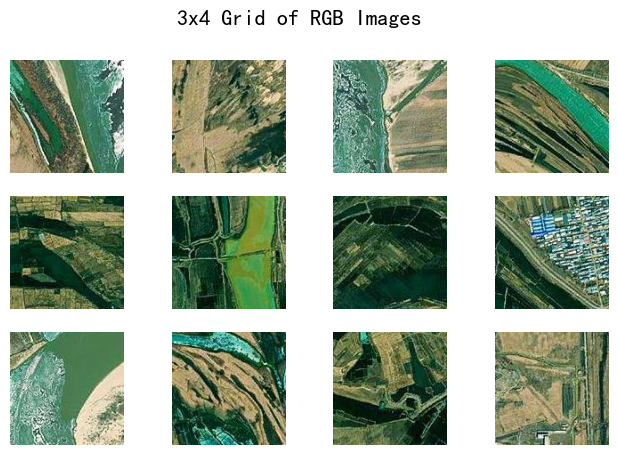

In [136]:
import os,glob
from PIL import Image
import matplotlib.pyplot as plt

image_files = glob.glob("./crops/*.jpg")
fig=plt.figure(figsize=(8,5)) #创建一个25*5的画布
plt.suptitle("3x4 Grid of RGB Images", fontsize=16)
for i in range(12): #循环12次，共12张图片
    data=Image.open(image_files[i]) #加载第i张图片
    plt.subplot(3,4,i+1) # 创建一个3*4的网格，当前位置为i+1
    plt.axis('off') # 不显示坐标
    plt.imshow(data) # 显示图像,data
plt.show()

折线图绘制

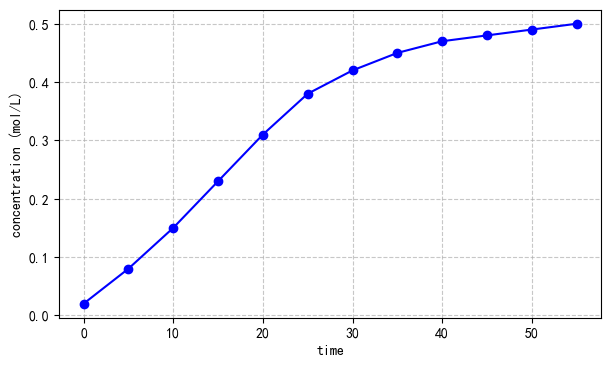

In [137]:
import matplotlib.pyplot as plt
import numpy as np

# 模拟数据：时间（分钟）与产物浓度（mol/L）
time = np.arange(0, 60, 5)
concentration = np.array([0.02, 0.08, 0.15, 0.23, 0.31, 0.38, 0.42, 0.45, 0.47, 0.48, 0.49, 0.50])

# 创建折线图
plt.figure(figsize=(7, 4))  # 设置画布大小
plt.plot(time, concentration, marker='o', linestyle='-', color='b')

# 添加科研图表必备元素
plt.xlabel('time', fontsize=10)
plt.ylabel('concentration (mol/L)', fontsize=10)
plt.grid(linestyle='--', alpha=0.7)  # 网格线辅助读数
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

散点趋势图绘制

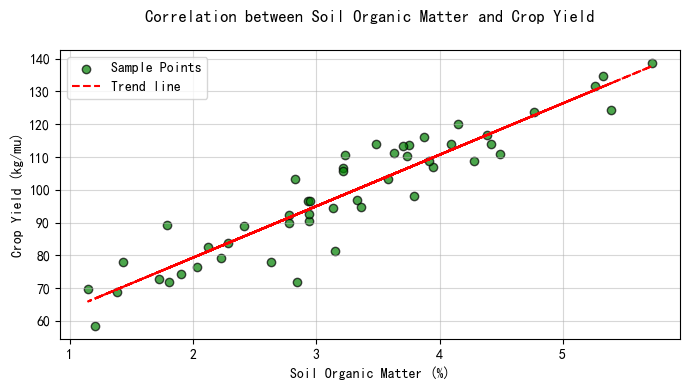

In [138]:
# 模拟数据：土壤有机质含量（%）与作物产量（kg/亩）
np.random.seed(42)  # 固定随机种子，使结果可复现
organic_matter = np.random.normal(3.5, 1.2, 50)  # 均值3.5，标准差1.2
yield_data = 50 + 15 * organic_matter + np.random.normal(0, 8, 50)  # 模拟正相关关系

plt.figure(figsize=(7,4))
plt.scatter(organic_matter, yield_data, c='g', alpha=0.7, edgecolors='k', label='Sample Points')

# 添加趋势线（一元线性回归）
z = np.polyfit(organic_matter, yield_data, 1)  # 计算回归系数
p = np.poly1d(z)  # 构造回归方程
plt.plot(organic_matter, p(organic_matter), 'r--', label=f'Trend line')

plt.xlabel('Soil Organic Matter (%)', fontsize=10)
plt.ylabel('Crop Yield (kg/mu)', fontsize=10)
plt.title('Correlation between Soil Organic Matter and Crop Yield', fontsize=12, pad=20)
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

出版级图表绘制

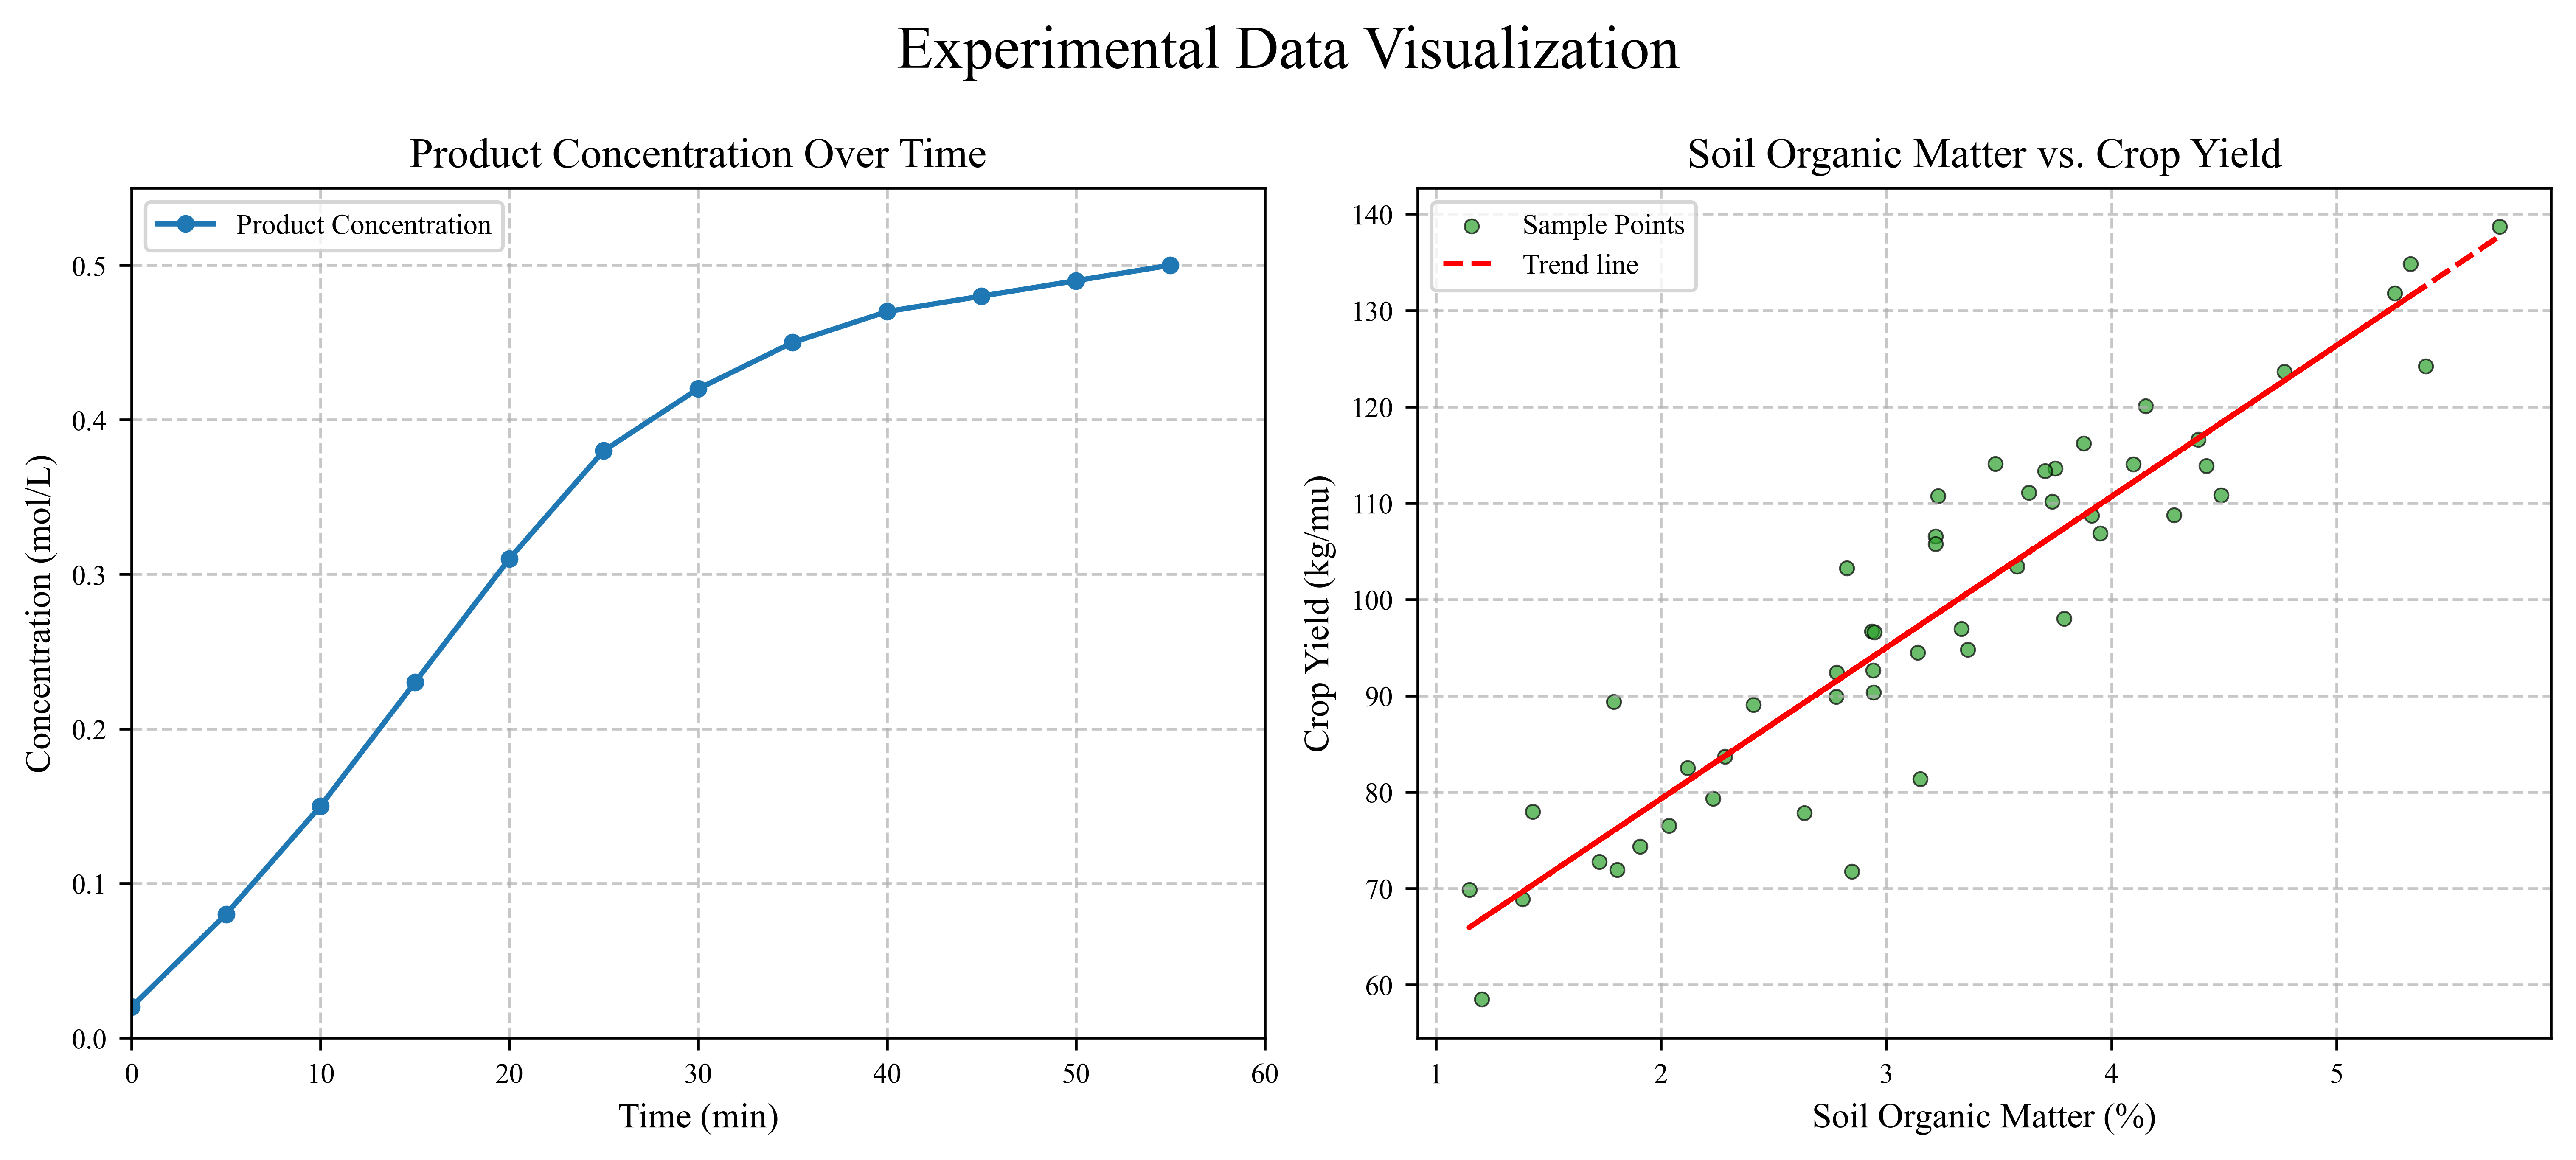

In [139]:
# 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# 配置出版级图表参数
rcParams.update({
    "font.family": "Times New Roman",  # 统一字体
    "font.size": 10,                   # 基础字体大小
    "axes.labelsize": 10,              # 坐标轴标签大小
    "axes.titlesize": 12,              # 子图标题大小
    "xtick.labelsize": 8,              # x轴刻度大小
    "ytick.labelsize": 8,              # y轴刻度大小
    "legend.fontsize": 8,              # 图例大小
    "lines.linewidth": 1.5,            # 线条宽度
    "lines.markersize": 4,             # 标记点大小
    "axes.grid": False,                # 默认关闭网格（按需开启）
    "figure.dpi": 600,                 # 图像分辨率
    "savefig.dpi": 600,                # 保存分辨率
    "savefig.bbox": "tight",           # 保存时紧凑布局
    "savefig.pad_inches": 0.1          # 保存时边距
})

# 创建1×2组合图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# --------------------------
# 左侧子图：产物浓度随时间变化
# --------------------------
time = np.arange(0, 60, 5)
concentration = np.array([0.02, 0.08, 0.15, 0.23, 0.31, 0.38, 0.42, 0.45, 0.47, 0.48, 0.49, 0.50])

# 绘制折线图
ax1.plot(time, concentration, marker='o', linestyle='-', color='#1f77b4', label='Product Concentration')  # 采用出版级配色
# 设置子图1属性
ax1.set_xlabel('Time (min)')
ax1.set_ylabel('Concentration (mol/L)')
ax1.set_title('Product Concentration Over Time')
ax1.legend(loc='upper left')  # 显示图例​
ax1.grid(linestyle='--', alpha=0.7)  # 开启网格
ax1.set_xlim(0, 60)                  # 固定x轴范围
ax1.set_ylim(0, 0.55)                # 固定y轴范围

# --------------------------
# 右侧子图：有机质与作物产量相关性
# --------------------------
np.random.seed(42)
organic_matter = np.random.normal(3.5, 1.2, 50)
yield_data = 50 + 15 * organic_matter + np.random.normal(0, 8, 50)

# 绘制散点图
sc = ax2.scatter(organic_matter, yield_data, c='#2ca02c', alpha=0.7, 
                 edgecolors='k', linewidth=0.5, label='Sample Points')

# 添加趋势线
z = np.polyfit(organic_matter, yield_data, 1)
p = np.poly1d(z)
ax2.plot(organic_matter, p(organic_matter), 'r--', label=f'Trend line')

# 设置子图2属性
ax2.set_xlabel('Soil Organic Matter (%)')
ax2.set_ylabel('Crop Yield (kg/mu)')
ax2.set_title('Soil Organic Matter vs. Crop Yield')
ax2.legend(loc='upper left')
ax2.grid(linestyle='--', alpha=0.7)

# 添加全局标题
fig.suptitle('Experimental Data Visualization', fontsize=17, y=1.1)  # 字体增大到16，y值调整间距

# 出版级输出（支持png、pdf、svg等格式）
plt.savefig('combined_plot.png', format='png', facecolor='white')
# plt.savefig('combined_plot.pdf', format='pdf')  # PDF格式适合矢量图需求

plt.show()

高光谱光谱曲线可视化

(5, 200)


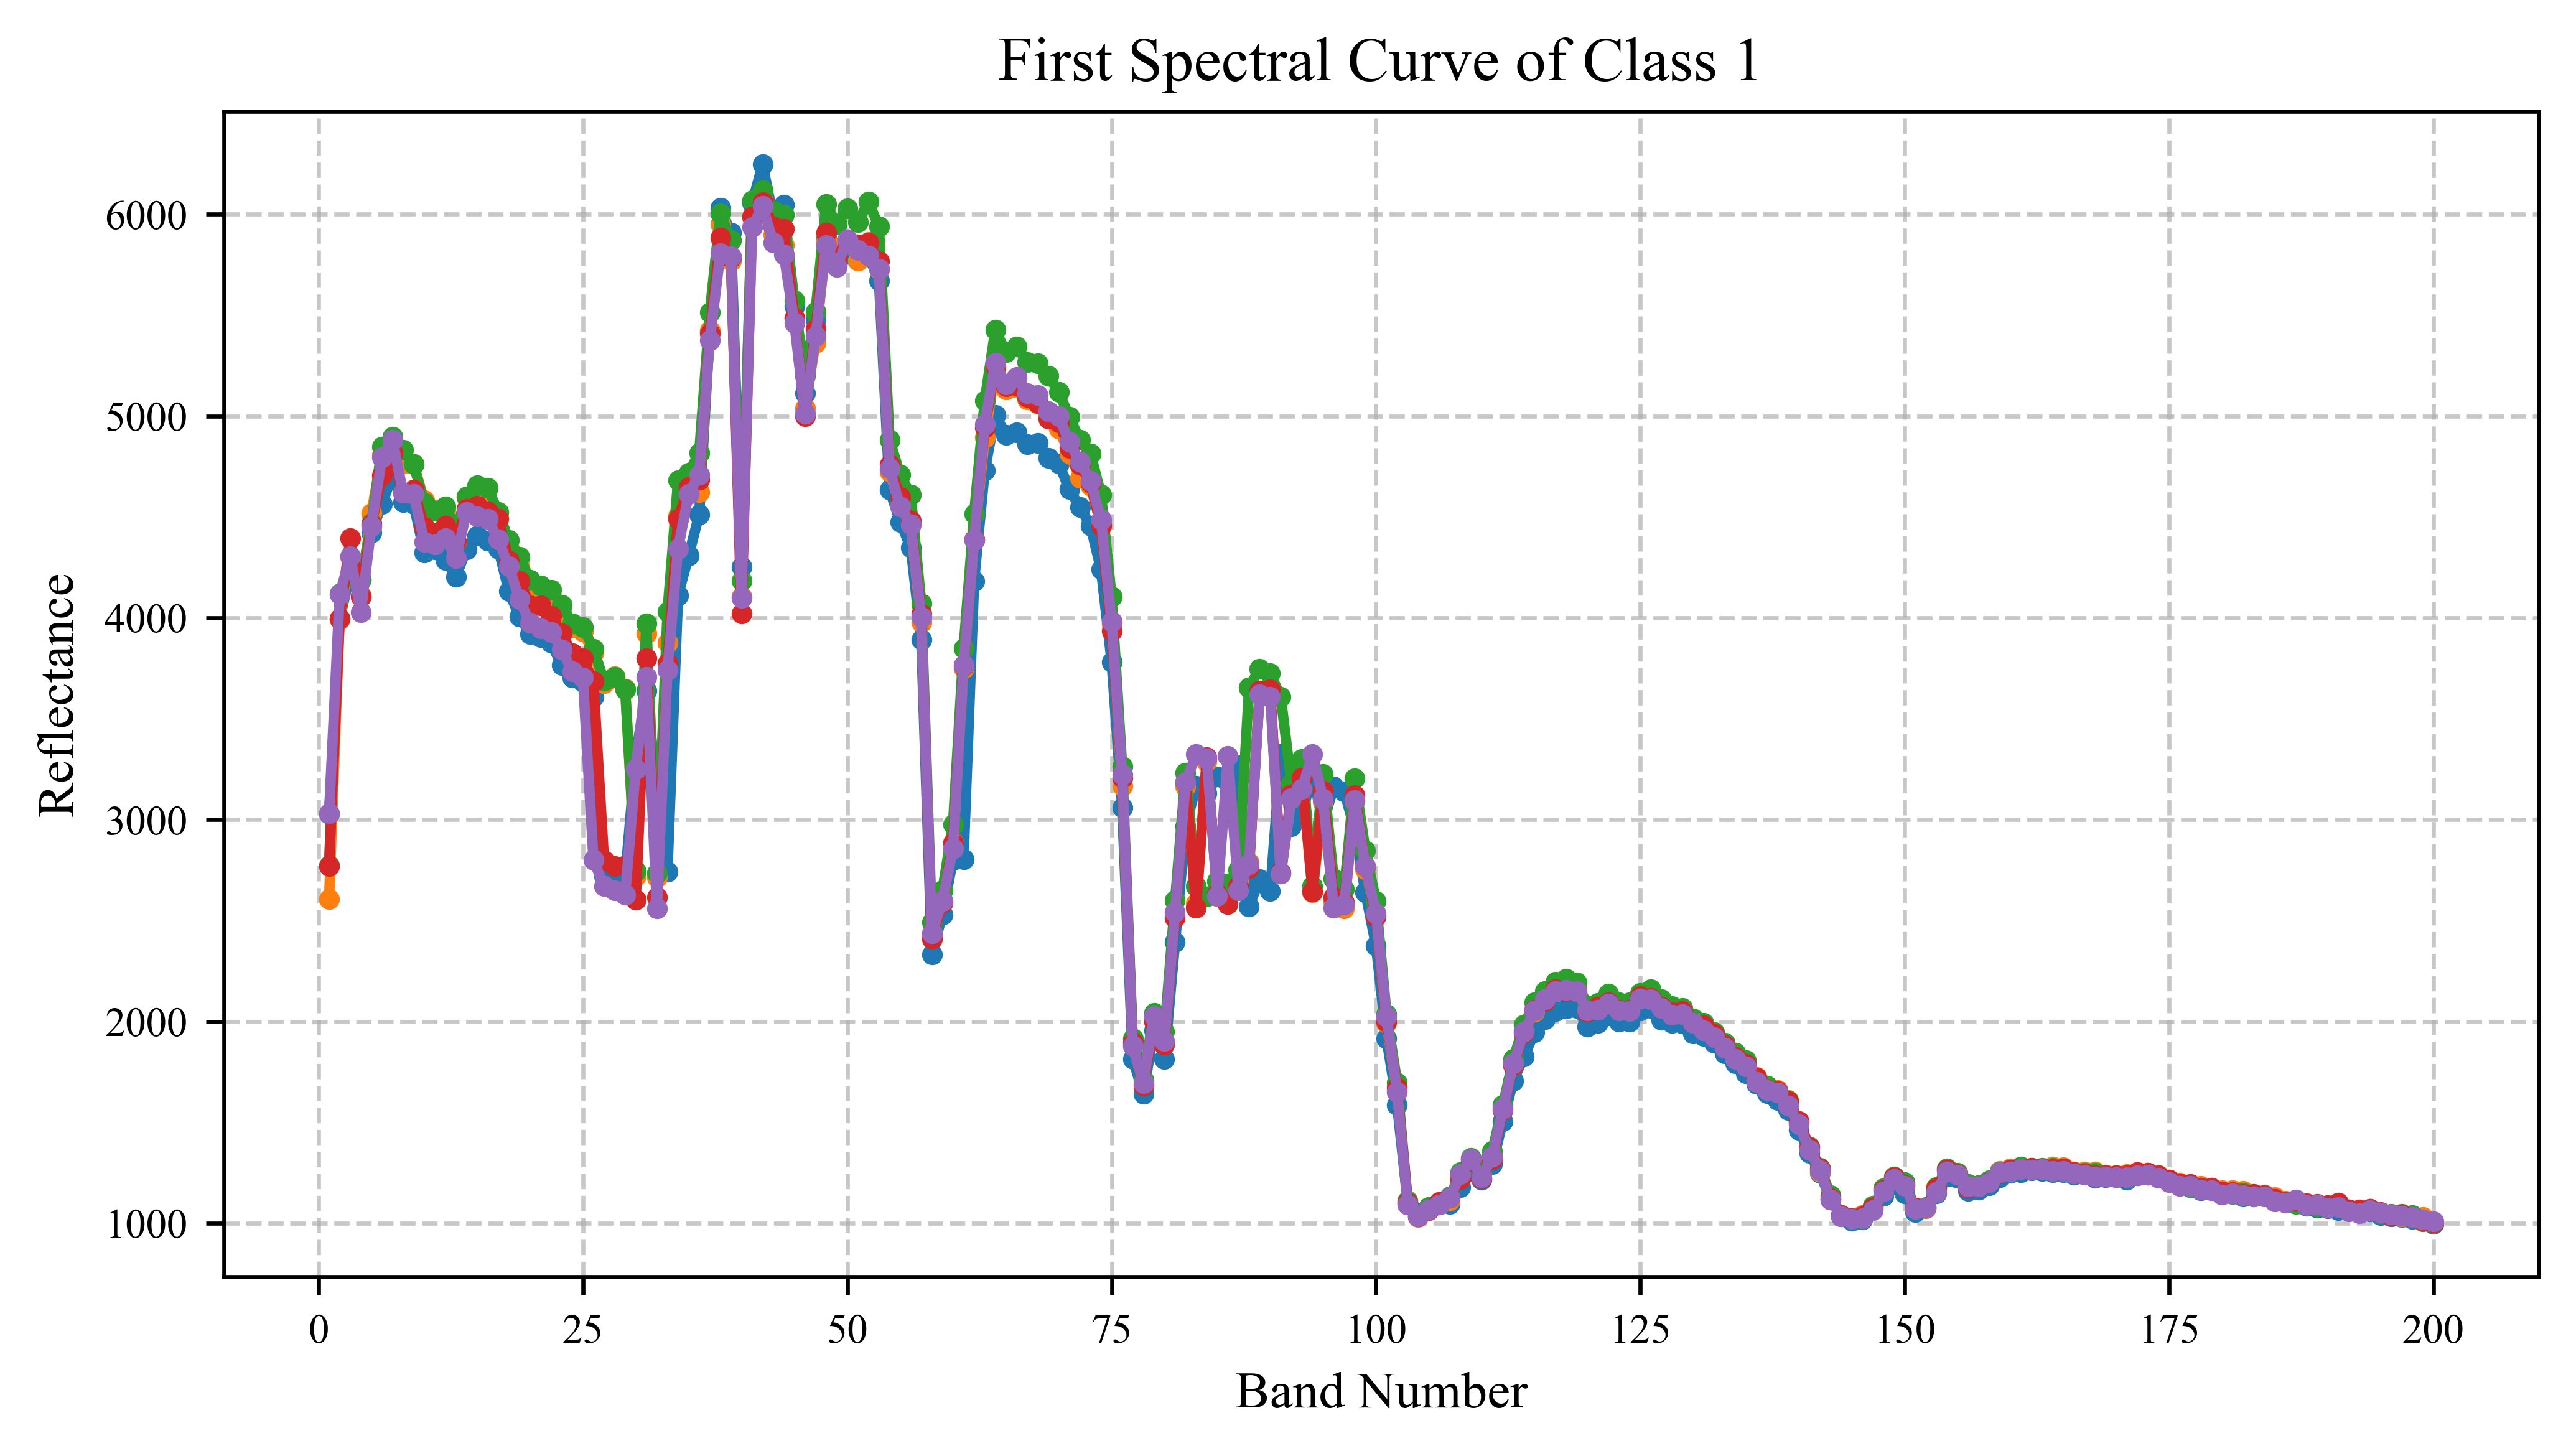

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('./Indian_pines.csv')
img = df.iloc[:, :-1].values  # 光谱数据 (总像元数, 通道数)
img_label = df.iloc[:, -1].values  # 分类标签
cls = 1

num_bands = img.shape[1] # 波段编号（x轴）
band_numbers = np.arange(1, num_bands + 1)

# 存储类别1前5条光谱
class_indices = np.where(img_label == cls)
first_spectrum = img[class_indices[0][:5], :]
print(first_spectrum.shape)
# 绘制第一条光谱曲线
plt.figure(figsize=(7,4))
plt.plot(band_numbers, first_spectrum.T, linewidth=2, marker='o', markersize=3)

# 图表要素
plt.title(f'First Spectral Curve of Class {cls}', fontsize=12)  # 标题仅保留类别1
plt.xlabel('Band Number')  
plt.ylabel('Reflectance')
plt.grid(alpha=0.7, linestyle='--')
plt.tight_layout()
plt.show()

混淆矩阵可视化

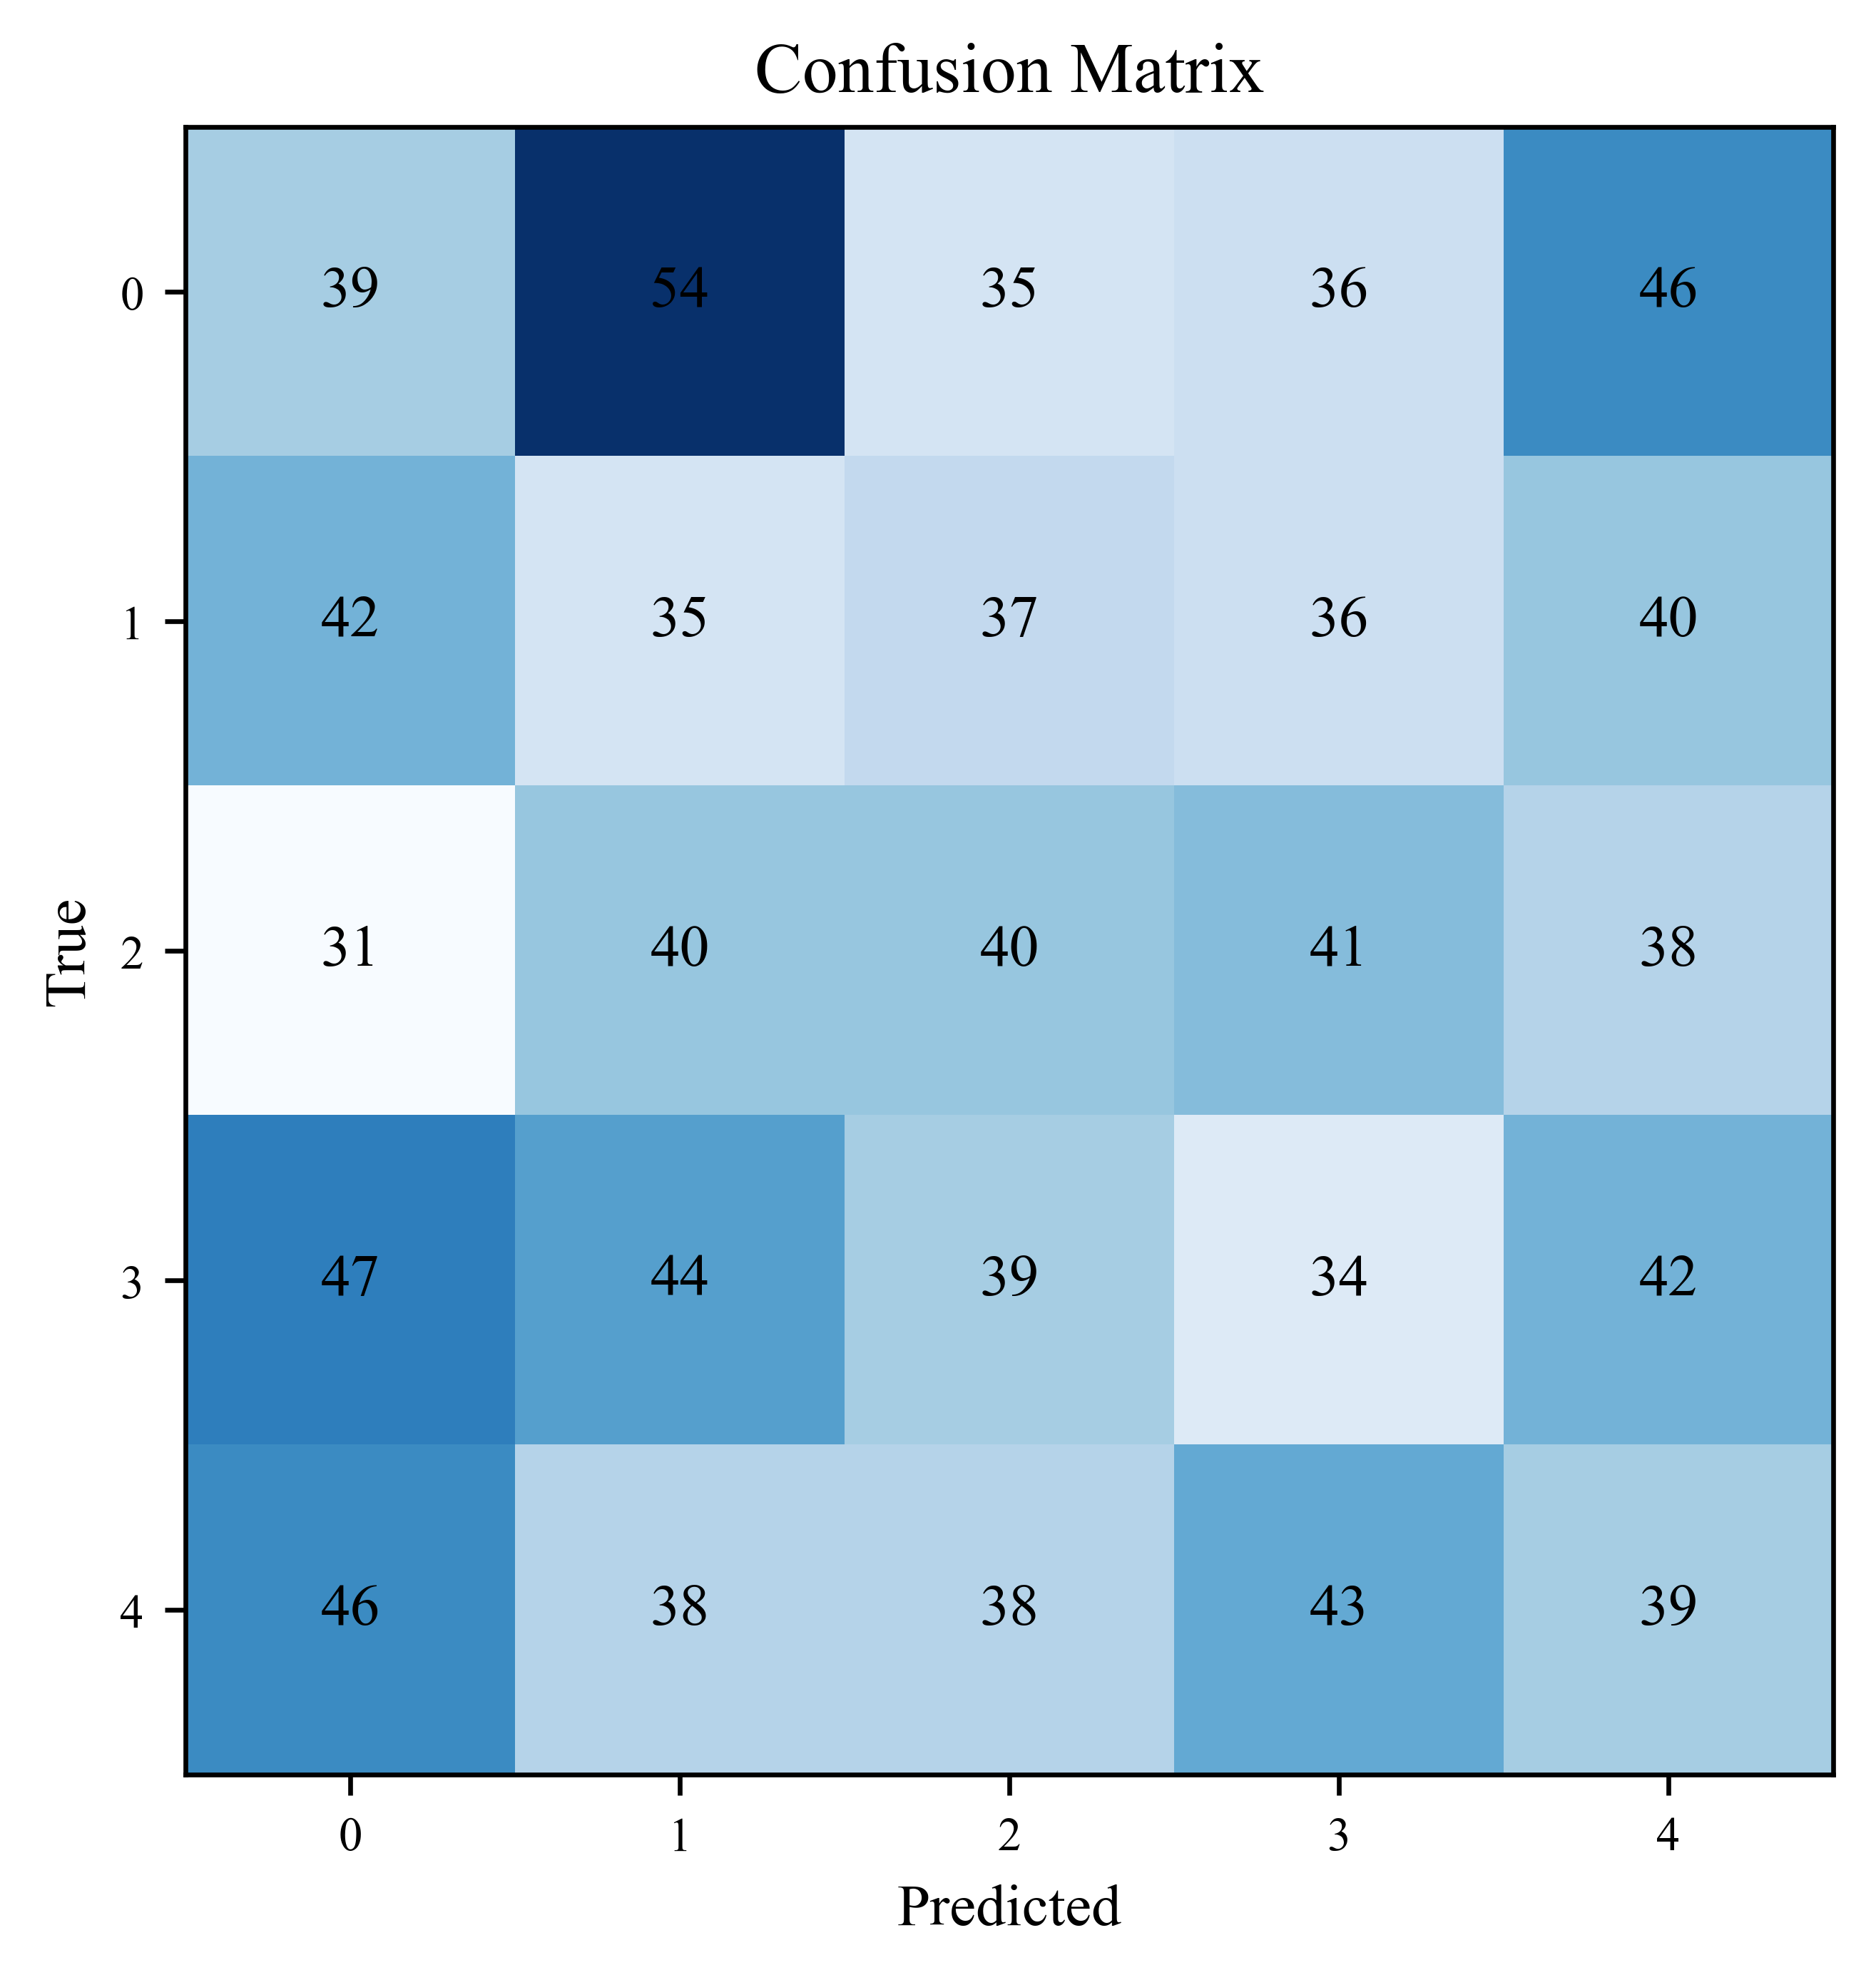

In [141]:
import numpy as np
import matplotlib.pyplot as plt

# 生成随机数据
np.random.seed(42)
num_classes = 5
data_size = 1000
true_labels = np.random.randint(0, num_classes, size=data_size)
predicted_labels = np.random.randint(0, num_classes, size=data_size)

# 计算混淆矩阵
confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)
for i in range(num_classes):
    for j in range(num_classes):
        confusion_matrix[i, j] = np.sum((true_labels == i) & (predicted_labels == j))

# 可视化
plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix, cmap='Blues')

# 添加基本标签
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

# 显示数值（可选）
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, confusion_matrix[i, j], ha='center', va='center')

plt.show()

#### 3.2. Seaborn库函数

Seaborn提供多种常用的数据可视化函数，使得创建各种图表变得简单。以下是一些常用函数的示例

<AxesSubplot: xlabel='total_bill', ylabel='tip'>

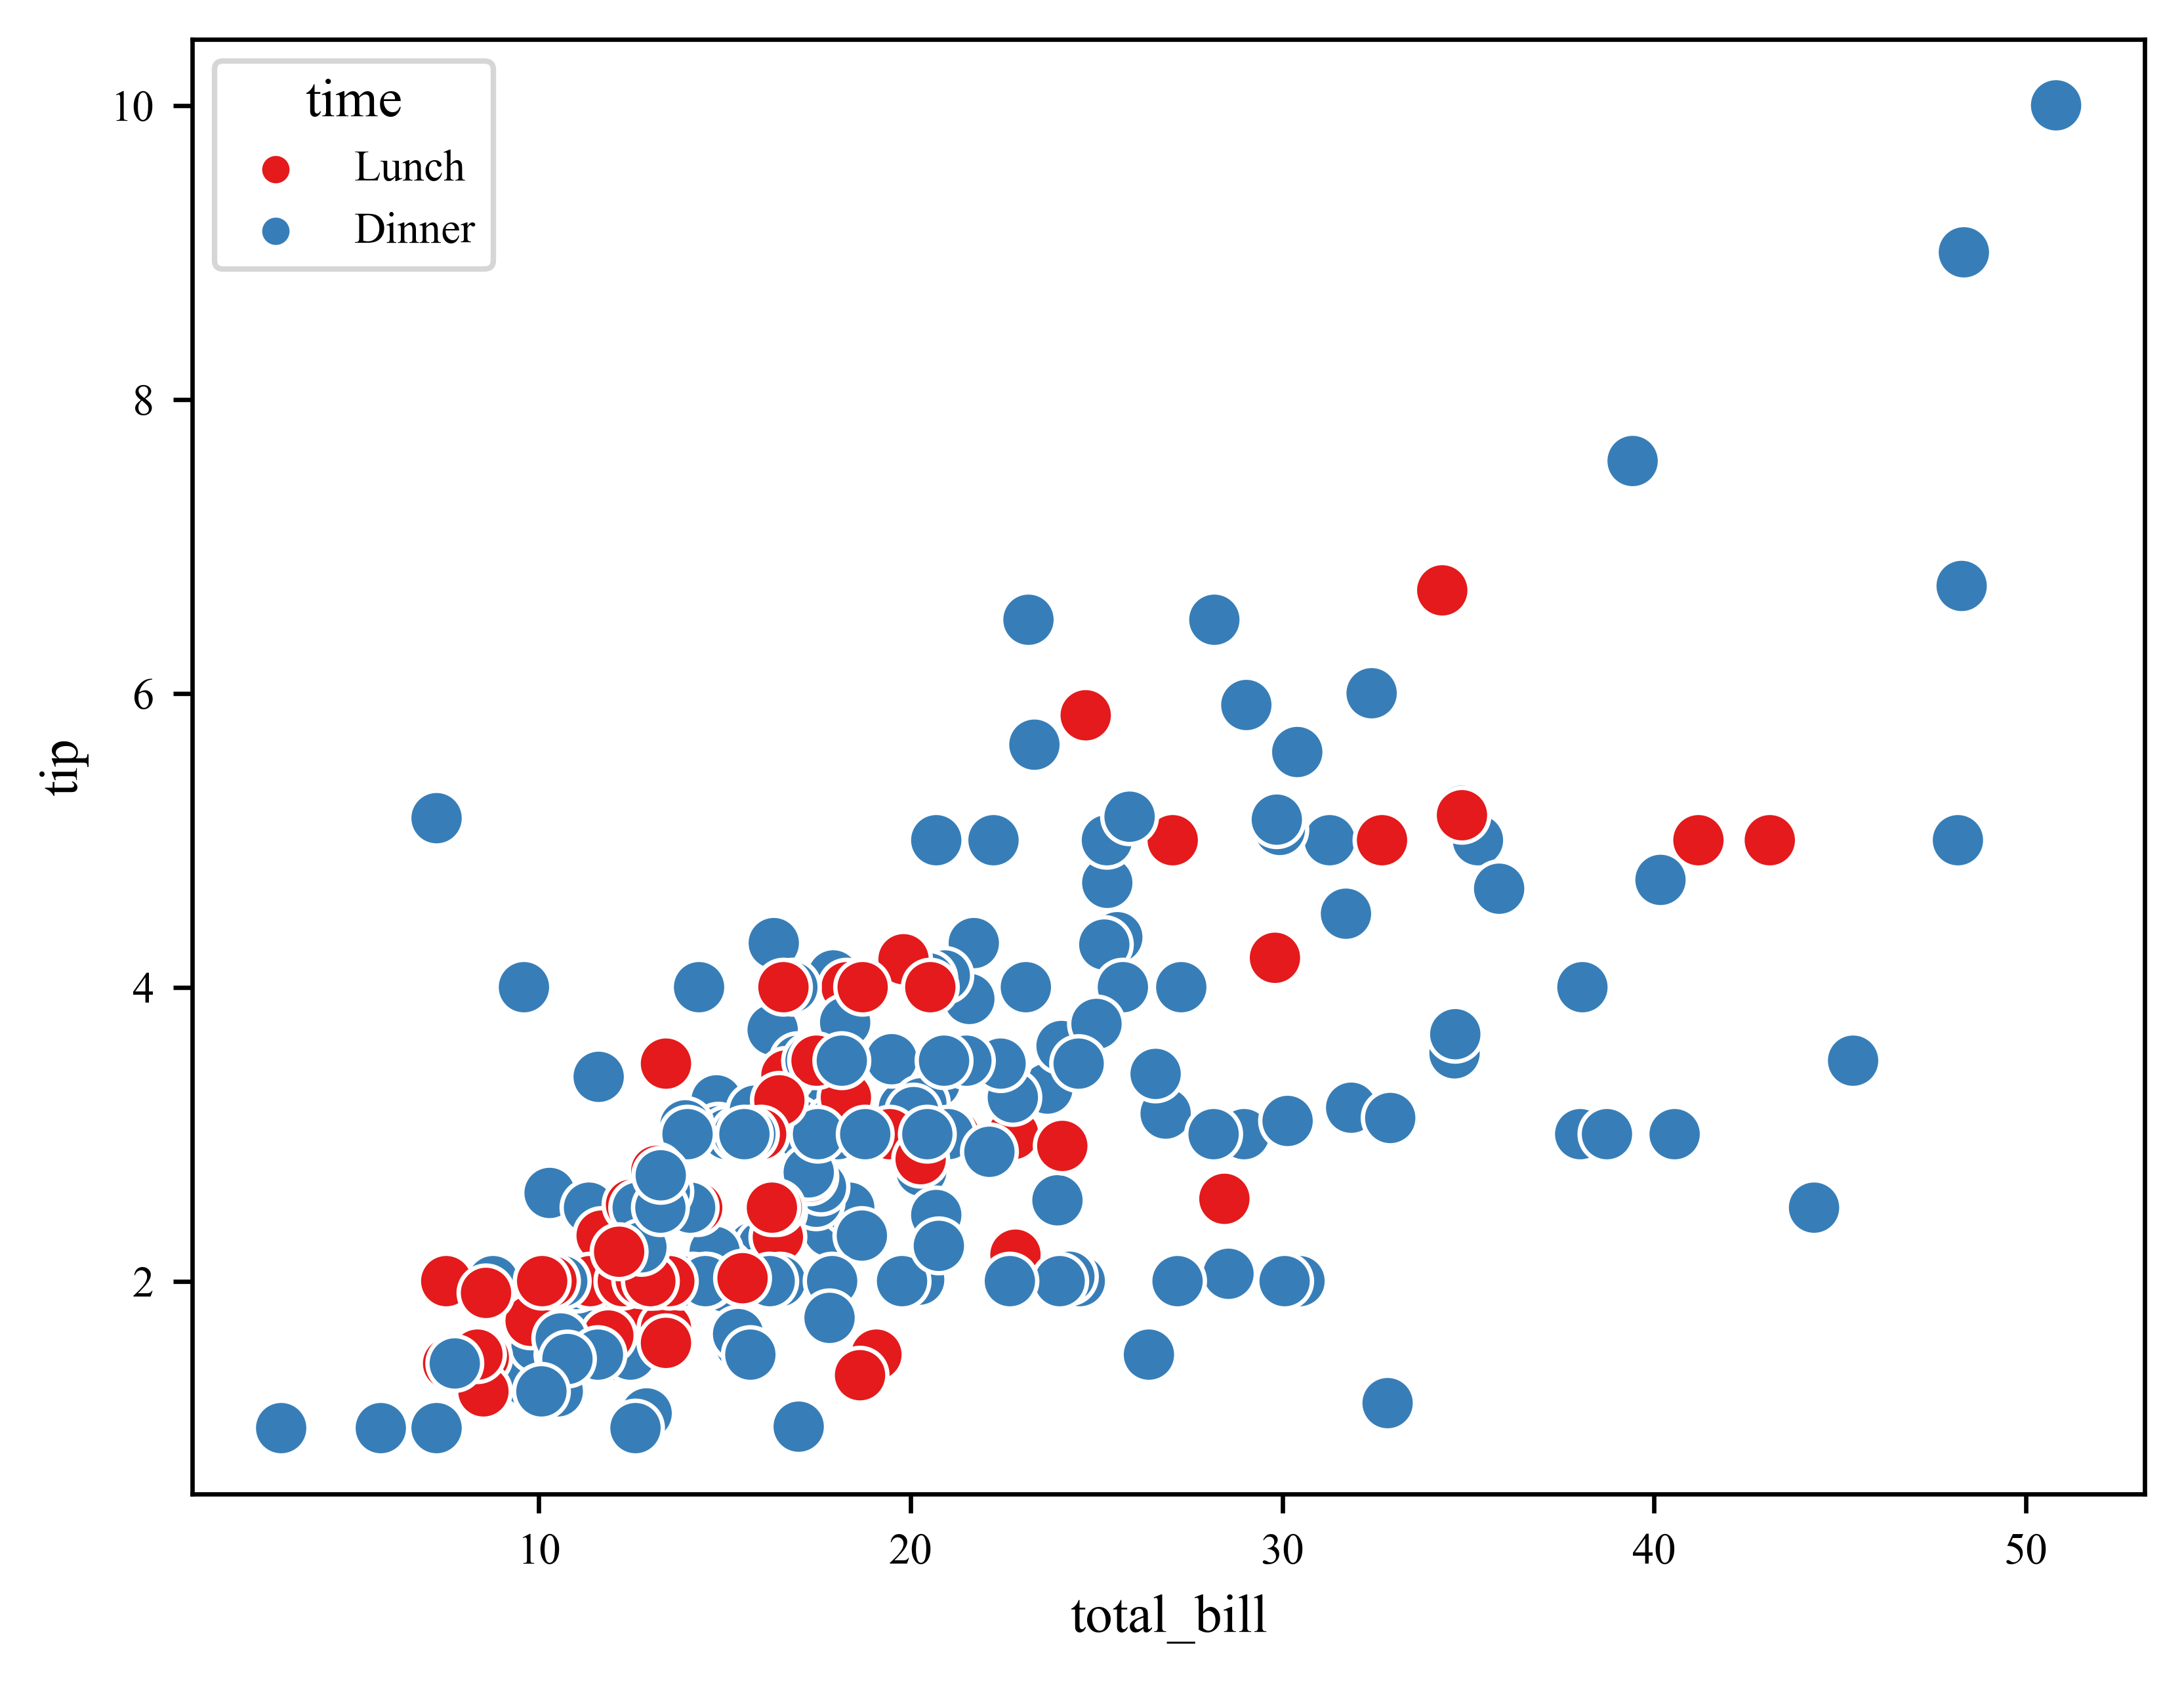

In [142]:
import seaborn as sns

# 加载示例数据，绘制散点图
data = sns.load_dataset("tips")
# 绘制散点图
sns.scatterplot(x="total_bill", y="tip", hue="time", data=data, palette="Set1", s=100)


<AxesSubplot: xlabel='total_bill', ylabel='Count'>

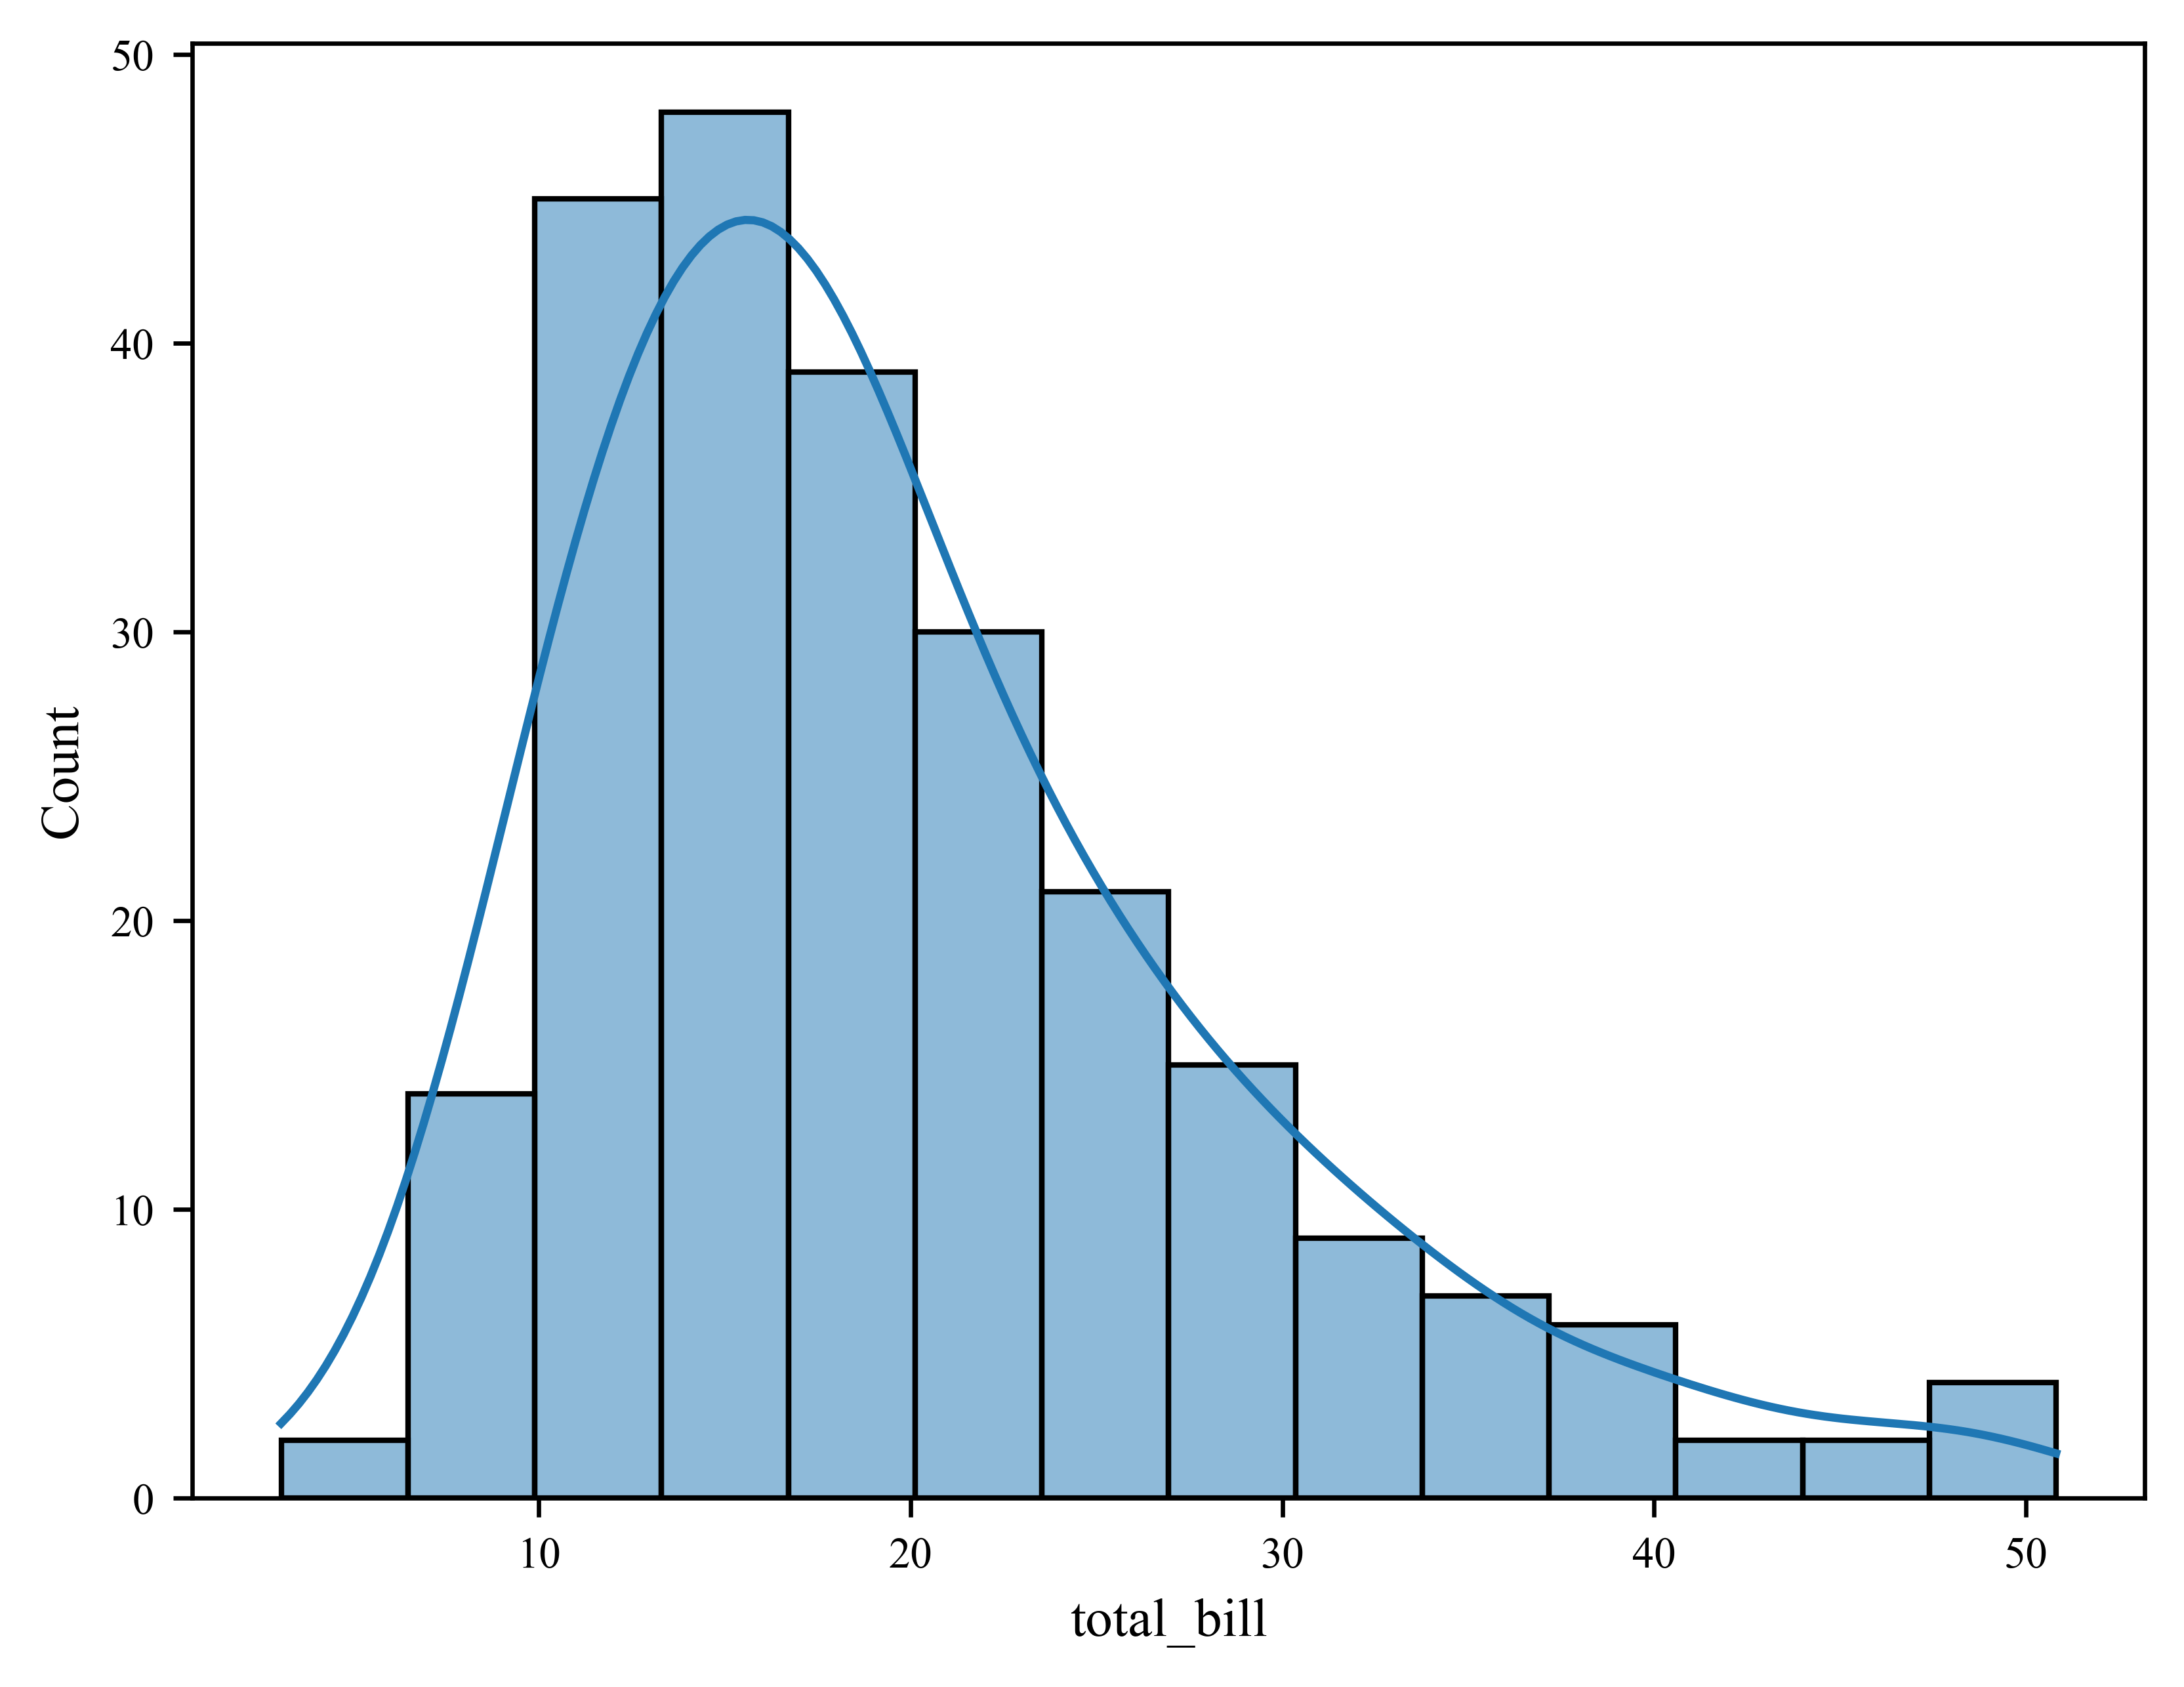

In [143]:
# 直方图
tips = sns.load_dataset("tips")
sns.histplot(data=tips, x="total_bill", kde=True)


<AxesSubplot: xlabel='day', ylabel='tip'>

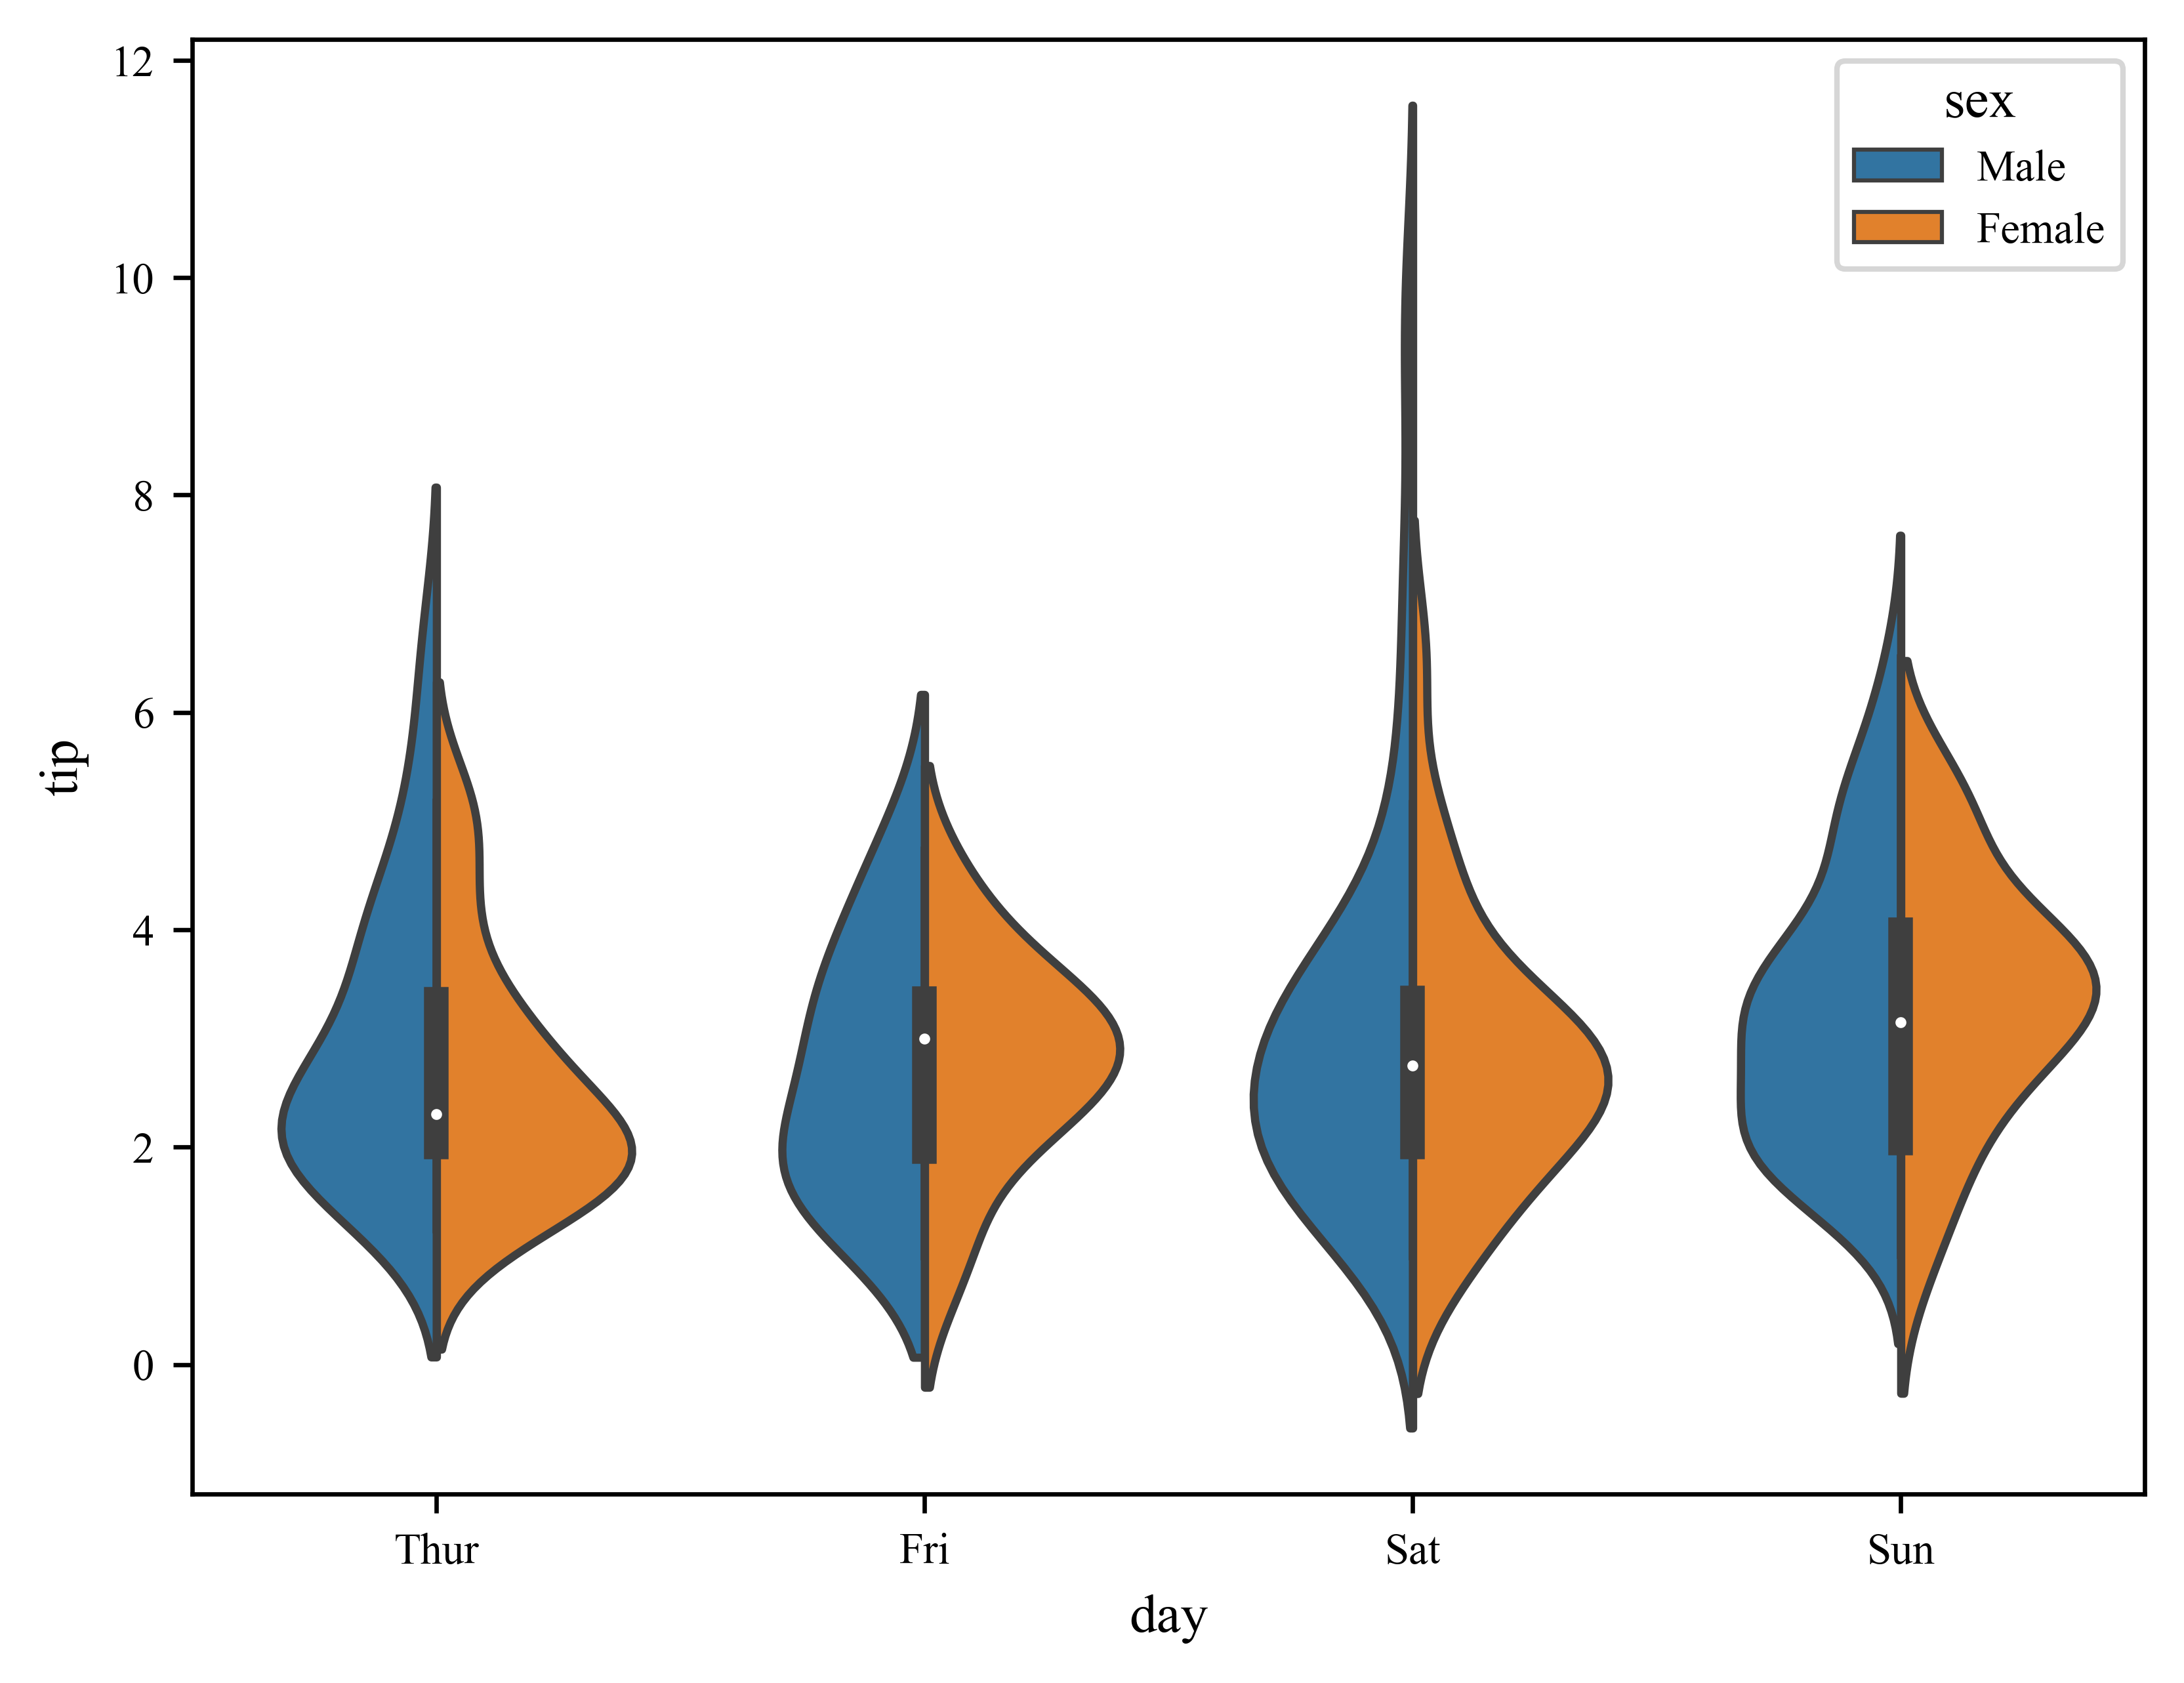

In [144]:
# 小提琴图
sns.violinplot(x="day", y="tip", data=tips, hue="sex", split=True)


<AxesSubplot: xlabel='year', ylabel='month'>

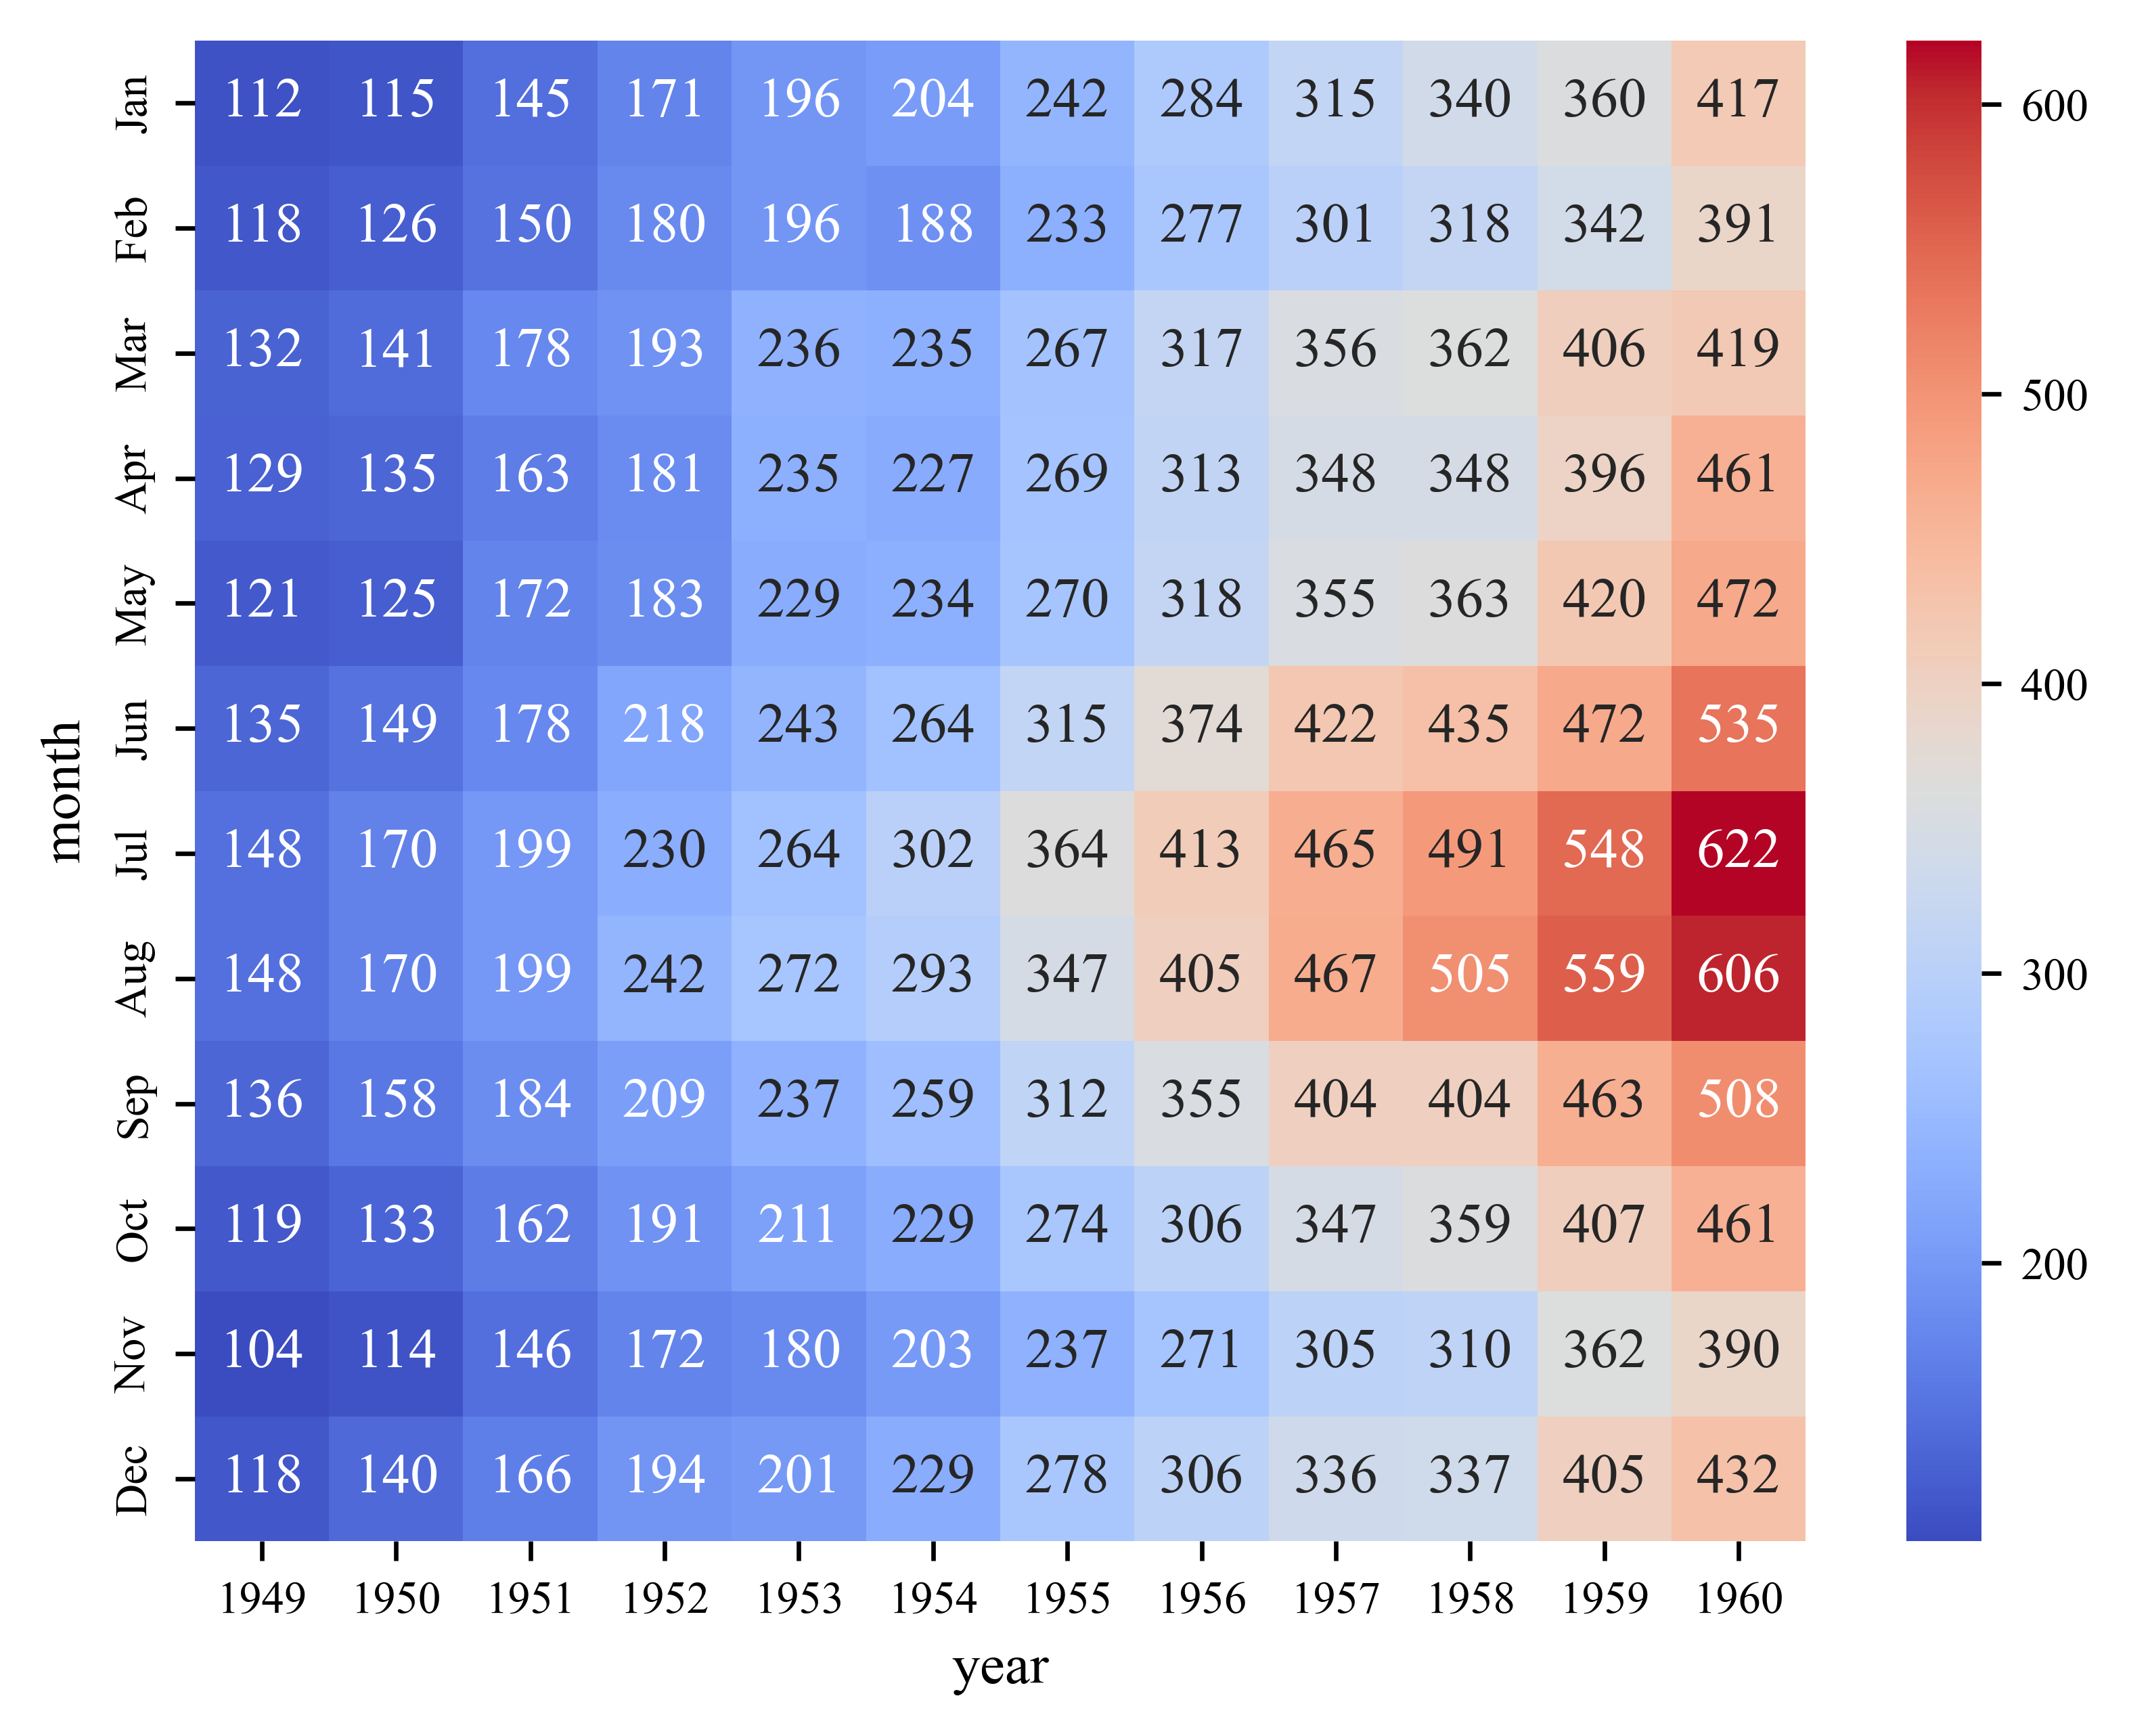

In [145]:
# 热力图
flights = sns.load_dataset("flights")
# 正确使用 pivot 方法，通过关键字参数指定
data = flights.pivot(index="month", columns="year", values="passengers")
# 绘制热力图
sns.heatmap(data, annot=True, fmt="d", cmap="coolwarm")


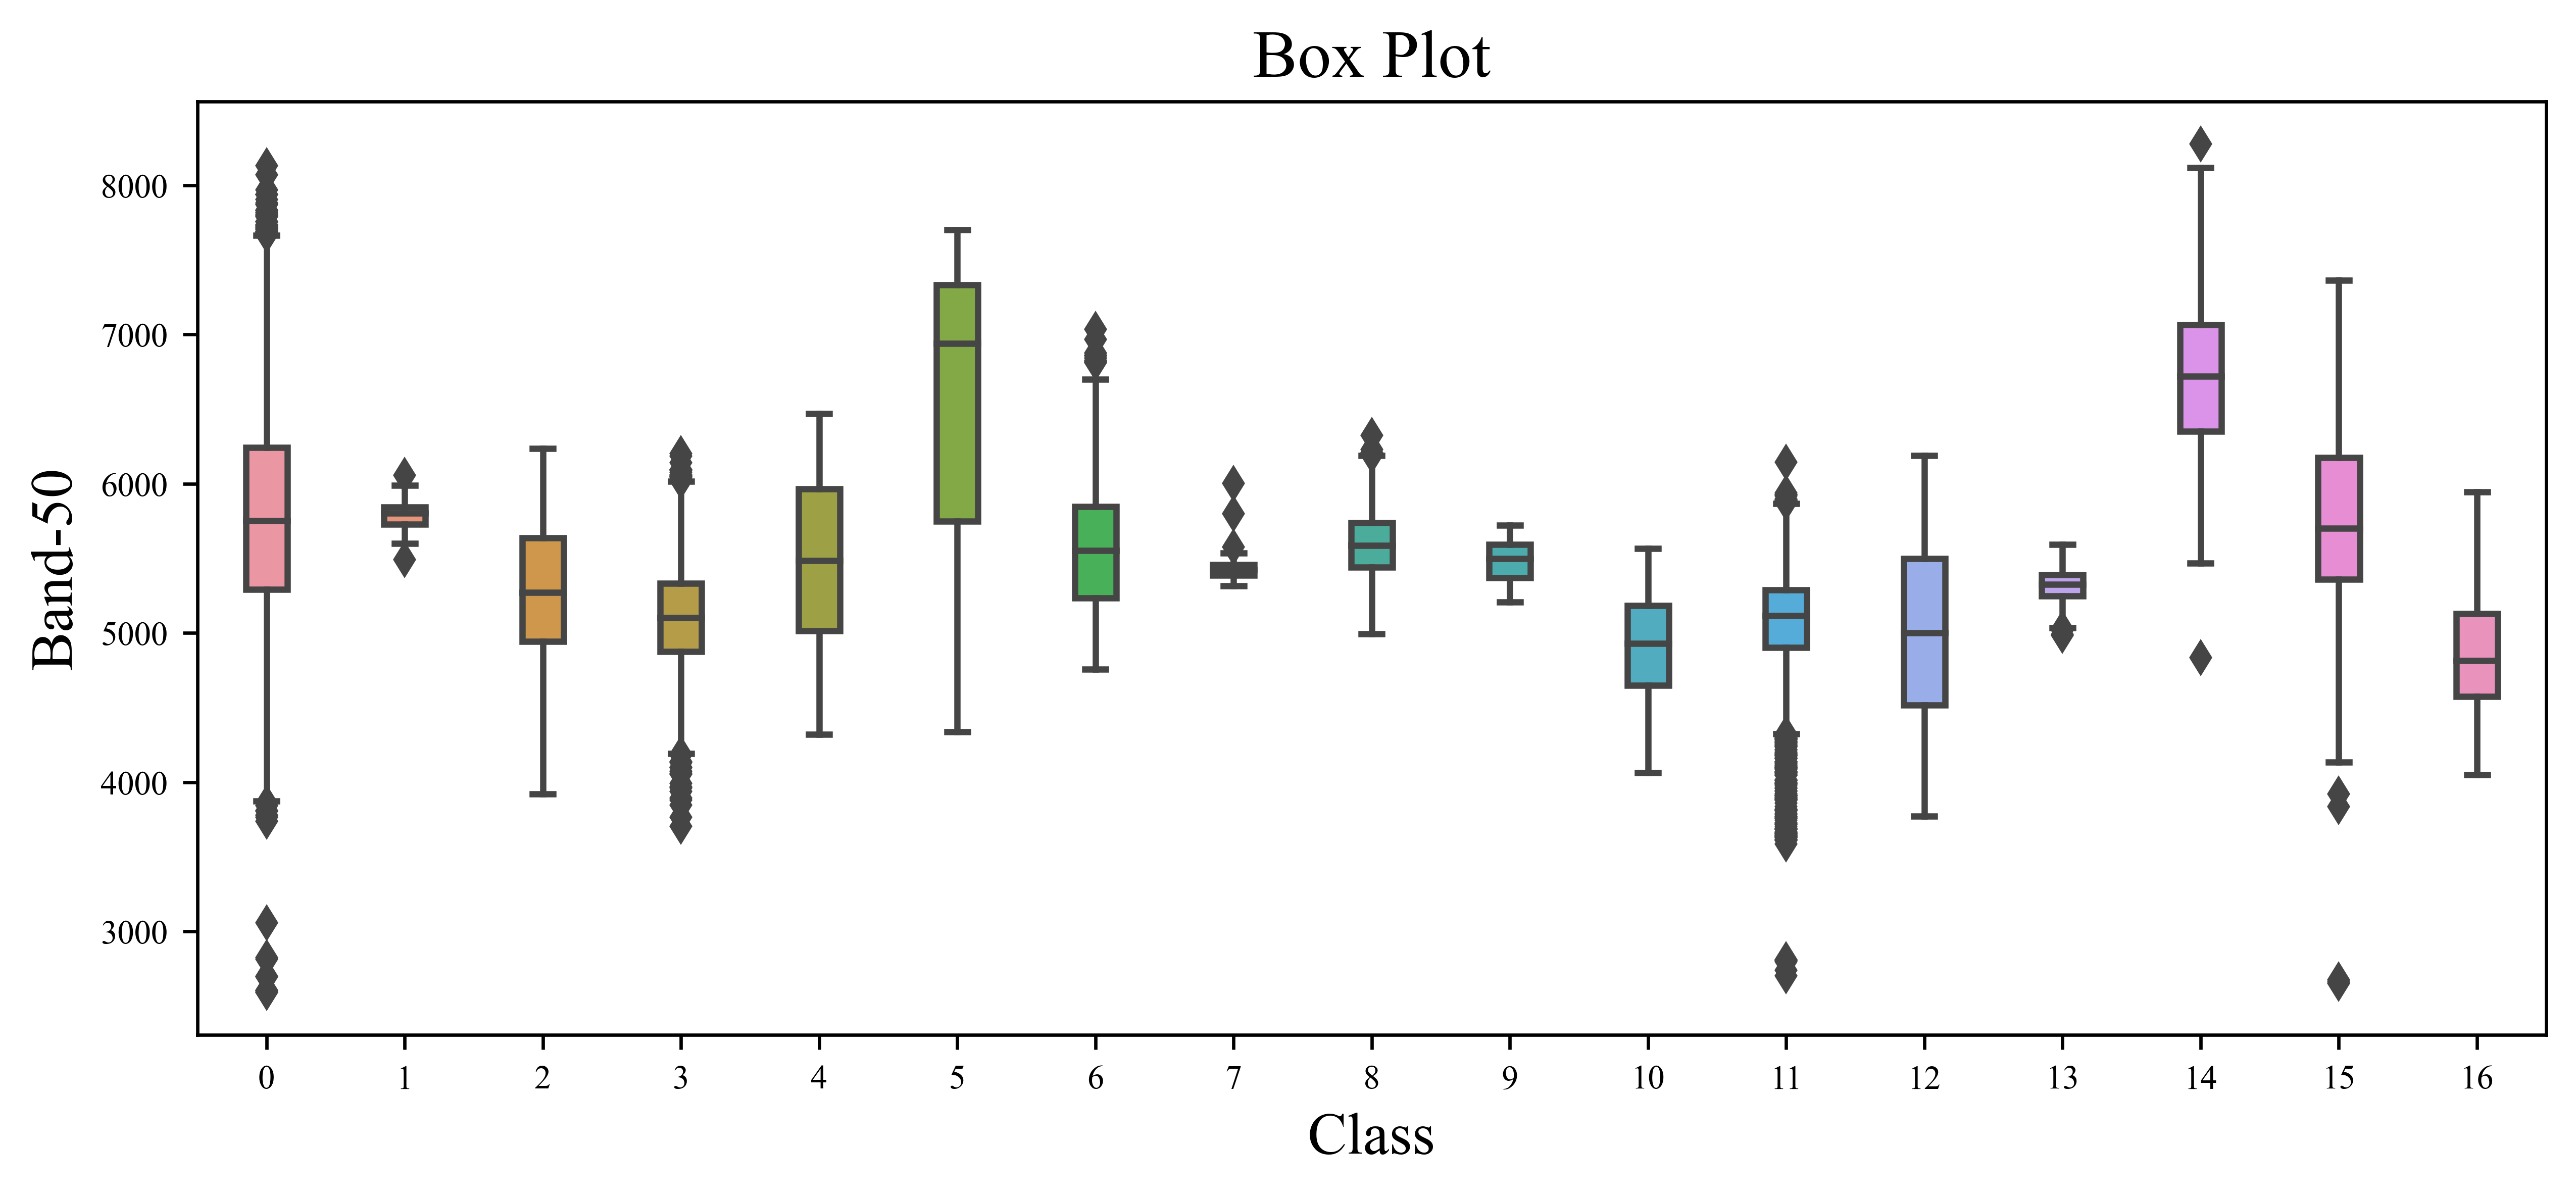

In [146]:
# 输入波段号，查看不同波段的箱线图
# img,img_label数据依然来自于前面读取的idian_pines.csv  
from matplotlib import pyplot as plt
plt.figure(figsize=(10,4))
sns.boxplot( x=img_label , y=img[:,50], width=0.3) # 箱线图
plt.title('Box Plot', fontsize= 16)
plt.xlabel('Class', fontsize= 14)
plt.ylabel(f'Band-{50}', fontsize= 14)
plt.show()

#### 3.3. scipy库函数

Correlation coefficient between the two bands: 0.9955403095982863


C:\Users\Administrator\AppData\Local\Temp\ipykernel_28500\2362163272.py:15: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


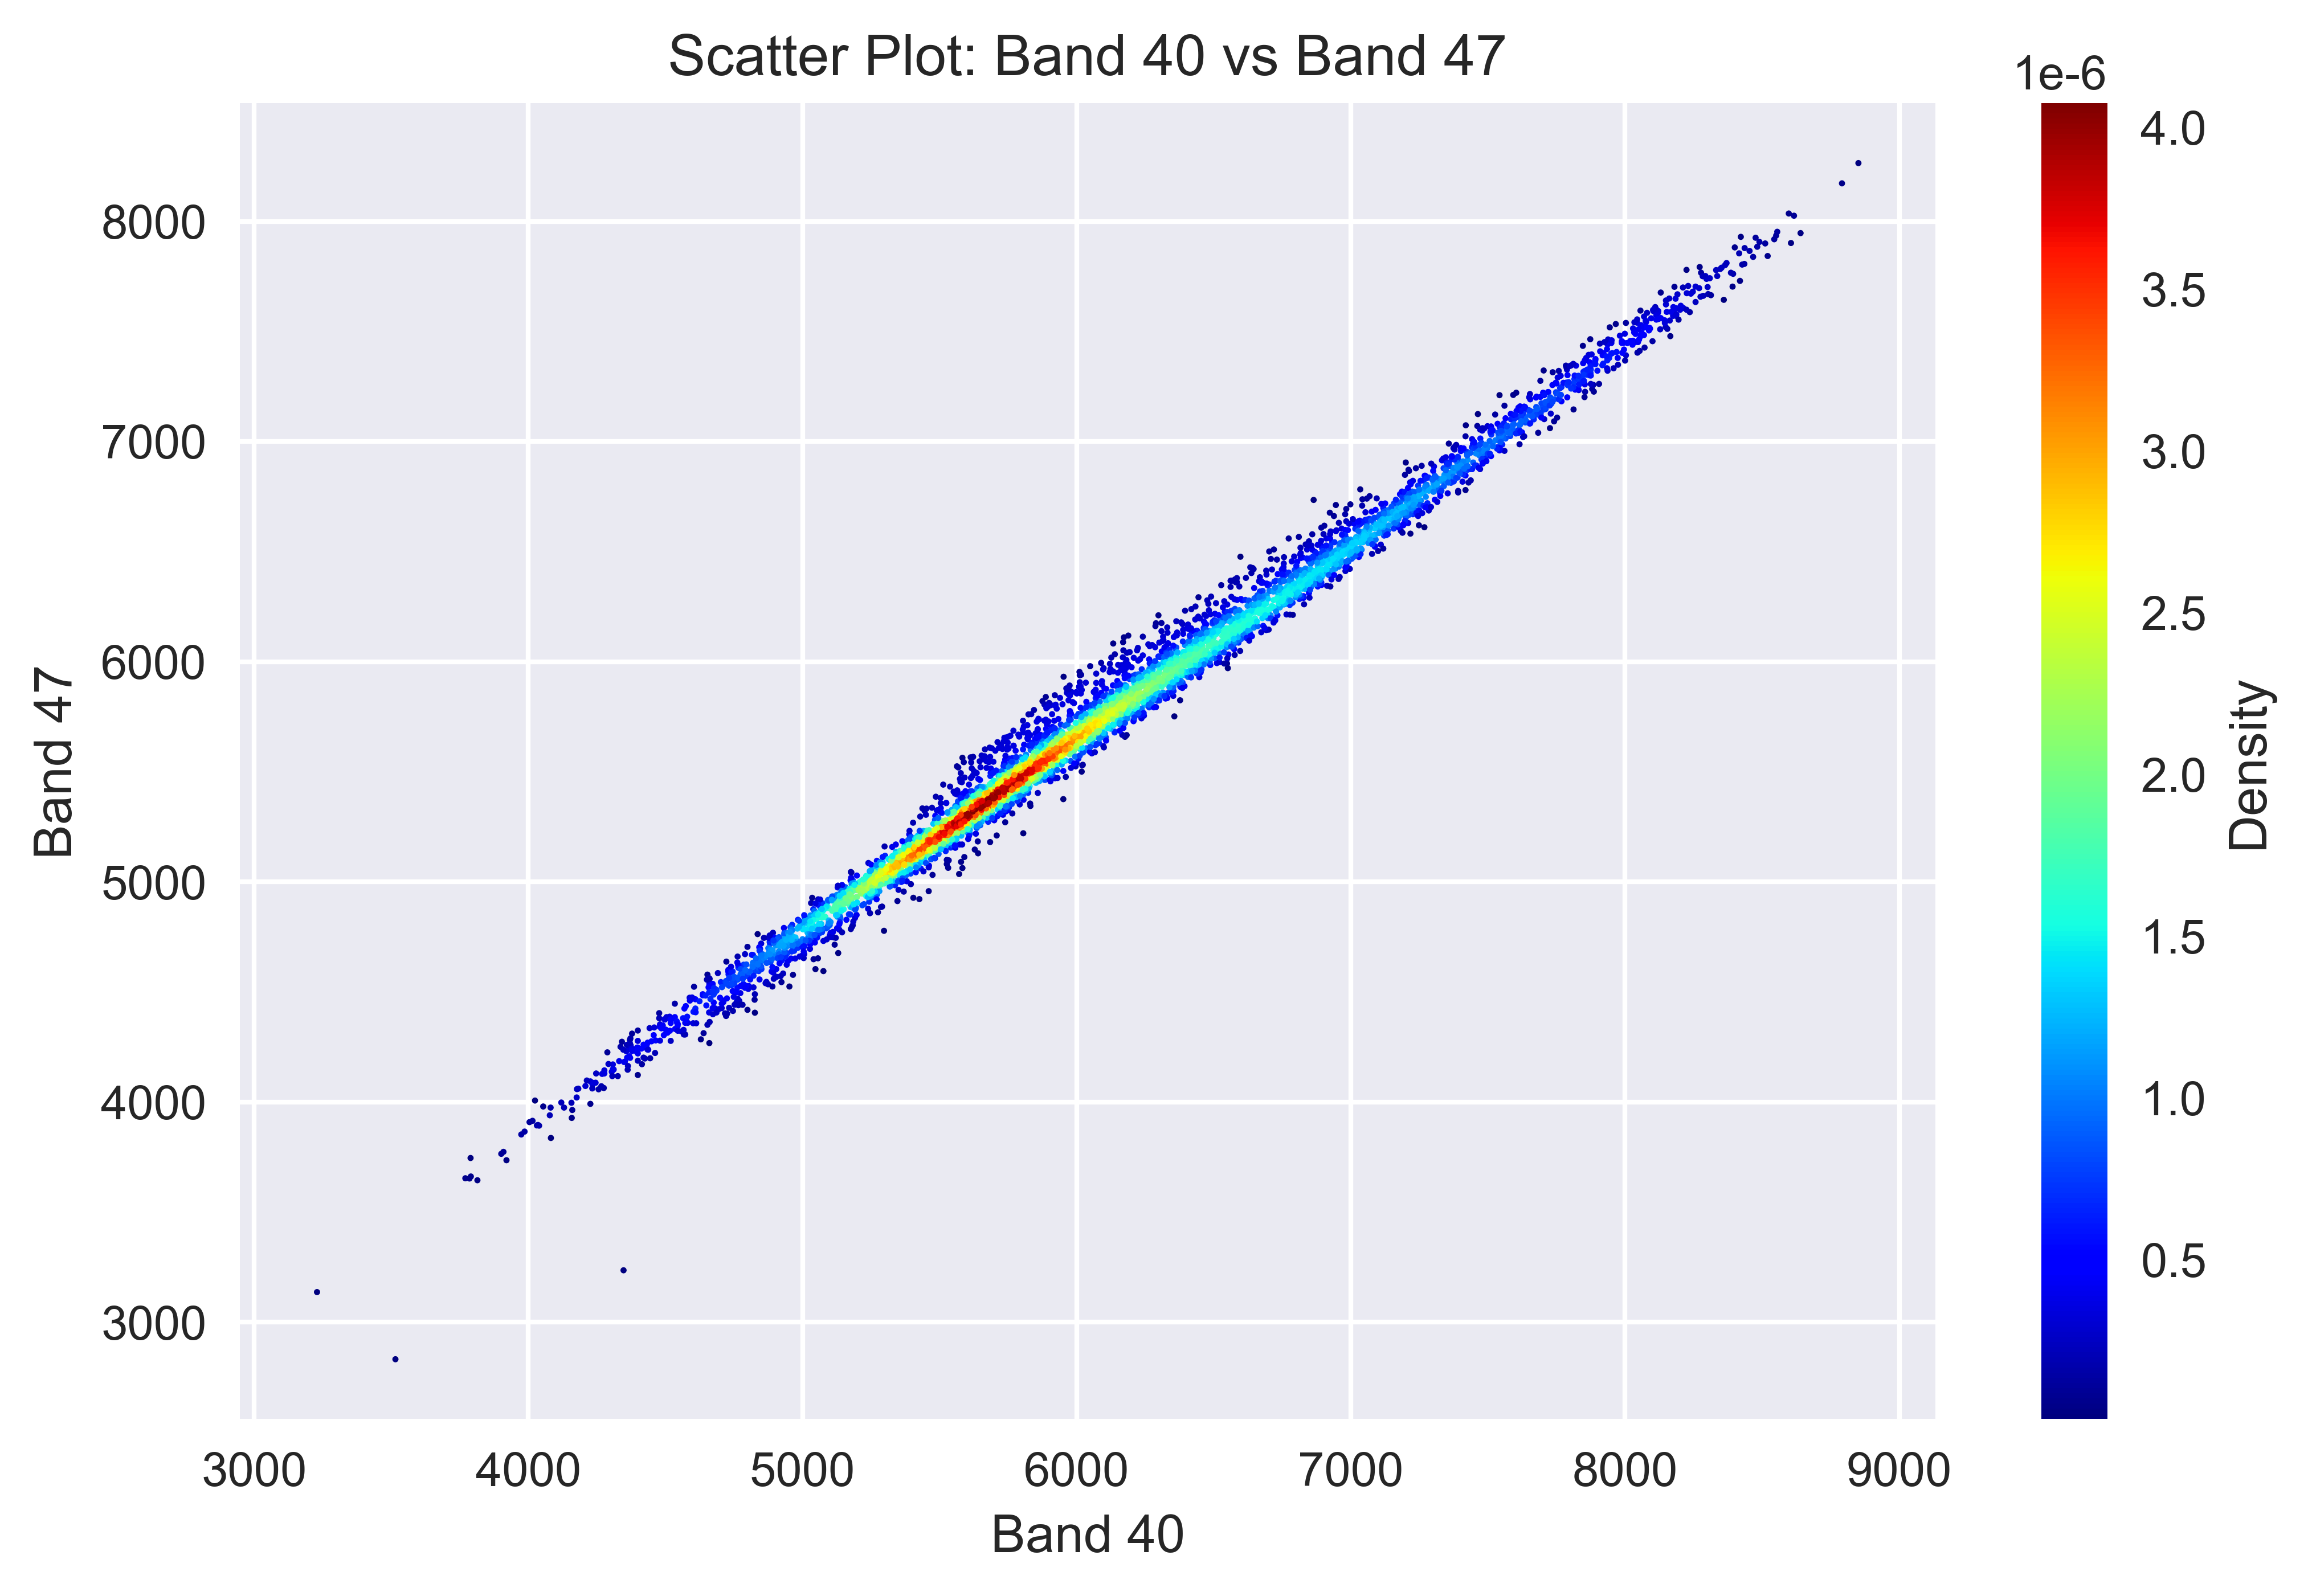

In [147]:
# 利用scipy制作散点密度图，考察高光谱相邻波段相似性

from scipy.ndimage import zoom
from scipy.stats import kde

def band_density(waveband_1, waveband_2,waveband_1_index,waveband_2_index):
    # 计算两个波段的相关性
    correlation = np.corrcoef(waveband_1.flatten(), waveband_2.flatten())[0, 1]
    print("Correlation coefficient between the two bands:", correlation)
    # 生成密度图数据
    xy = np.vstack([waveband_1.flatten(), waveband_2.flatten()])
    density = kde.gaussian_kde(xy)(xy)
    # 绘制散点图
    fig = plt.figure(figsize=(8, 5))
    plt.style.use('seaborn')
    plt.scatter(waveband_1.flatten(), waveband_2.flatten(), c=density, s=1,cmap='jet')
    plt.xlabel('Band ' + str(waveband_1_index))
    plt.ylabel('Band ' + str(waveband_2_index))
    plt.title('Scatter Plot: Band ' + str(waveband_1_index) + ' vs Band ' + str(waveband_2_index))
    # 添加色标
    colorbar = plt.colorbar()
    colorbar.set_label('Density')
    plt.show()
    
# img,img_label数据依然来自于前面读取的idian_pines.csv    
indianp_img=np.reshape(img,(145,145,200))
indianp_lab=np.reshape(img_label,(145,145))
# 使用zoom函数进行1/2重采样
banda = zoom(indianp_img[:,:,40], 0.5, order=1)
bandb = zoom(indianp_img[:,:,47], 0.5, order=1)
band_density(banda,bandb,40,47)

### 🏁**4. 效率工具: tqdm、argparse**

#### 4.1 tqdm库函数

tqdm是一个快速、可扩展的Python进度条库，用于在Python长循环中添加一个进度提示信息，用户只需封装任何迭代器 tqdm(iterator)，适合于各种循环任务，特别是在数据处理和机器学习领域中。
tqdm 其名字意为“进步”或“进展”。

直接传入可迭代对象

In [148]:
import time
from tqdm import trange, tqdm

for i in tqdm(range(60)):
    time.sleep(0.01)

100%|██████████| 60/60 [00:00<00:00, 64.69it/s]


使用trange(i)

In [149]:
for t in trange(60):
    time.sleep(0.01)

100%|██████████| 60/60 [00:00<00:00, 64.28it/s]


#### 4.2 argparse库函数


 argparse主要用于解析命令行参数和选项。相对于sys.argv，argparse提供了更方便、更清晰的接口，并且支持类型转换、默认值、帮助信息等功能。在py和jupyter中均适用。

In [150]:
import argparse

def multiply(a, b):
    return float(a) * float(b)

# 创建 ArgumentParser 对象
parser = argparse.ArgumentParser()
parser.add_argument('num1', type=float, help='第一个数字')
parser.add_argument('num2', type=float, help='第二个数字')
print(parser)
# 在 Jupyter 中直接传递参数列表
args = parser.parse_args(['3', '2'])  # 模拟输入的值
# 在 py 中自动解析传递参数列表
# args = parser.parse_args()  

print(f"接收的参数分别为: {args.num1}, {args.num2}")
result = multiply(args.num1, args.num2)
print(f"乘积结果: {result}")

ArgumentParser(prog='ipykernel_launcher.py', usage=None, description=None, formatter_class=<class 'argparse.HelpFormatter'>, conflict_handler='error', add_help=True)
接收的参数分别为: 3.0, 2.0
乘积结果: 6.0


### 🚀**5. 完成一个小任务**

##### 5.1 获取测试文件夹中的所有影像的文件名，保存为一个csv文件

In [151]:
import os
import pandas as pd

# 设置文件路径
file_path = './crops'

# 建立空列表用于存储文件名
code_list = []

# 遍历目录及其子目录
for root, dirs, files in os.walk(file_path):
    for filename in files:
        # 去掉文件扩展名并加入列表
        code_list.append(filename[:-4])

# 将列表转换为DataFrame
df = pd.DataFrame(code_list, columns=['filename'])

# 保存为CSV文件
df.to_csv('filenames.csv', index=False)

##### 5.2 将所有3月份的文件拷贝到测试文件夹的子文件夹中，拷贝过程中要用tadm显示进度条

In [152]:
import os
import shutil
from tqdm import tqdm

source_folder = 'crops'  # 源文件夹
dest_folder = os.path.join('test_folder', 'month_03')  # 目标文件夹

# 收集所有3月份的文件
files = []
for filename in os.listdir(source_folder):
    file_path = os.path.join(source_folder, filename)
    if os.path.isfile(file_path) and filename.startswith('img_') and '-03-' in filename:
        files.append(filename)

# 创建目标文件夹（如果不存在）
os.makedirs(dest_folder, exist_ok=True)

# 使用 tqdm 显示进度条
with tqdm(total=len(files), desc="Copying March files", unit="file") as pbar:
    for filename in files:
        src_path = os.path.join(source_folder, filename)
        dest_path = os.path.join(dest_folder, filename)
        shutil.copy2(src_path, dest_path)
        pbar.update(1)

print(f"\n✅ 已成功复制 {len(files)} 张3月份的图片到 {dest_folder}")

Copying March files: 100%|██████████| 12/12 [00:00<00:00, 17.06file/s]


✅ 已成功复制 12 张3月份的图片到 test_folder\month_03


##### 5.3 读取testdata中的信息，利用反射率绘制折线图，统计不同类别地物的高程和绘制直方图，将两个子图拼接成一个完整的图片，并添加图面可视化元素

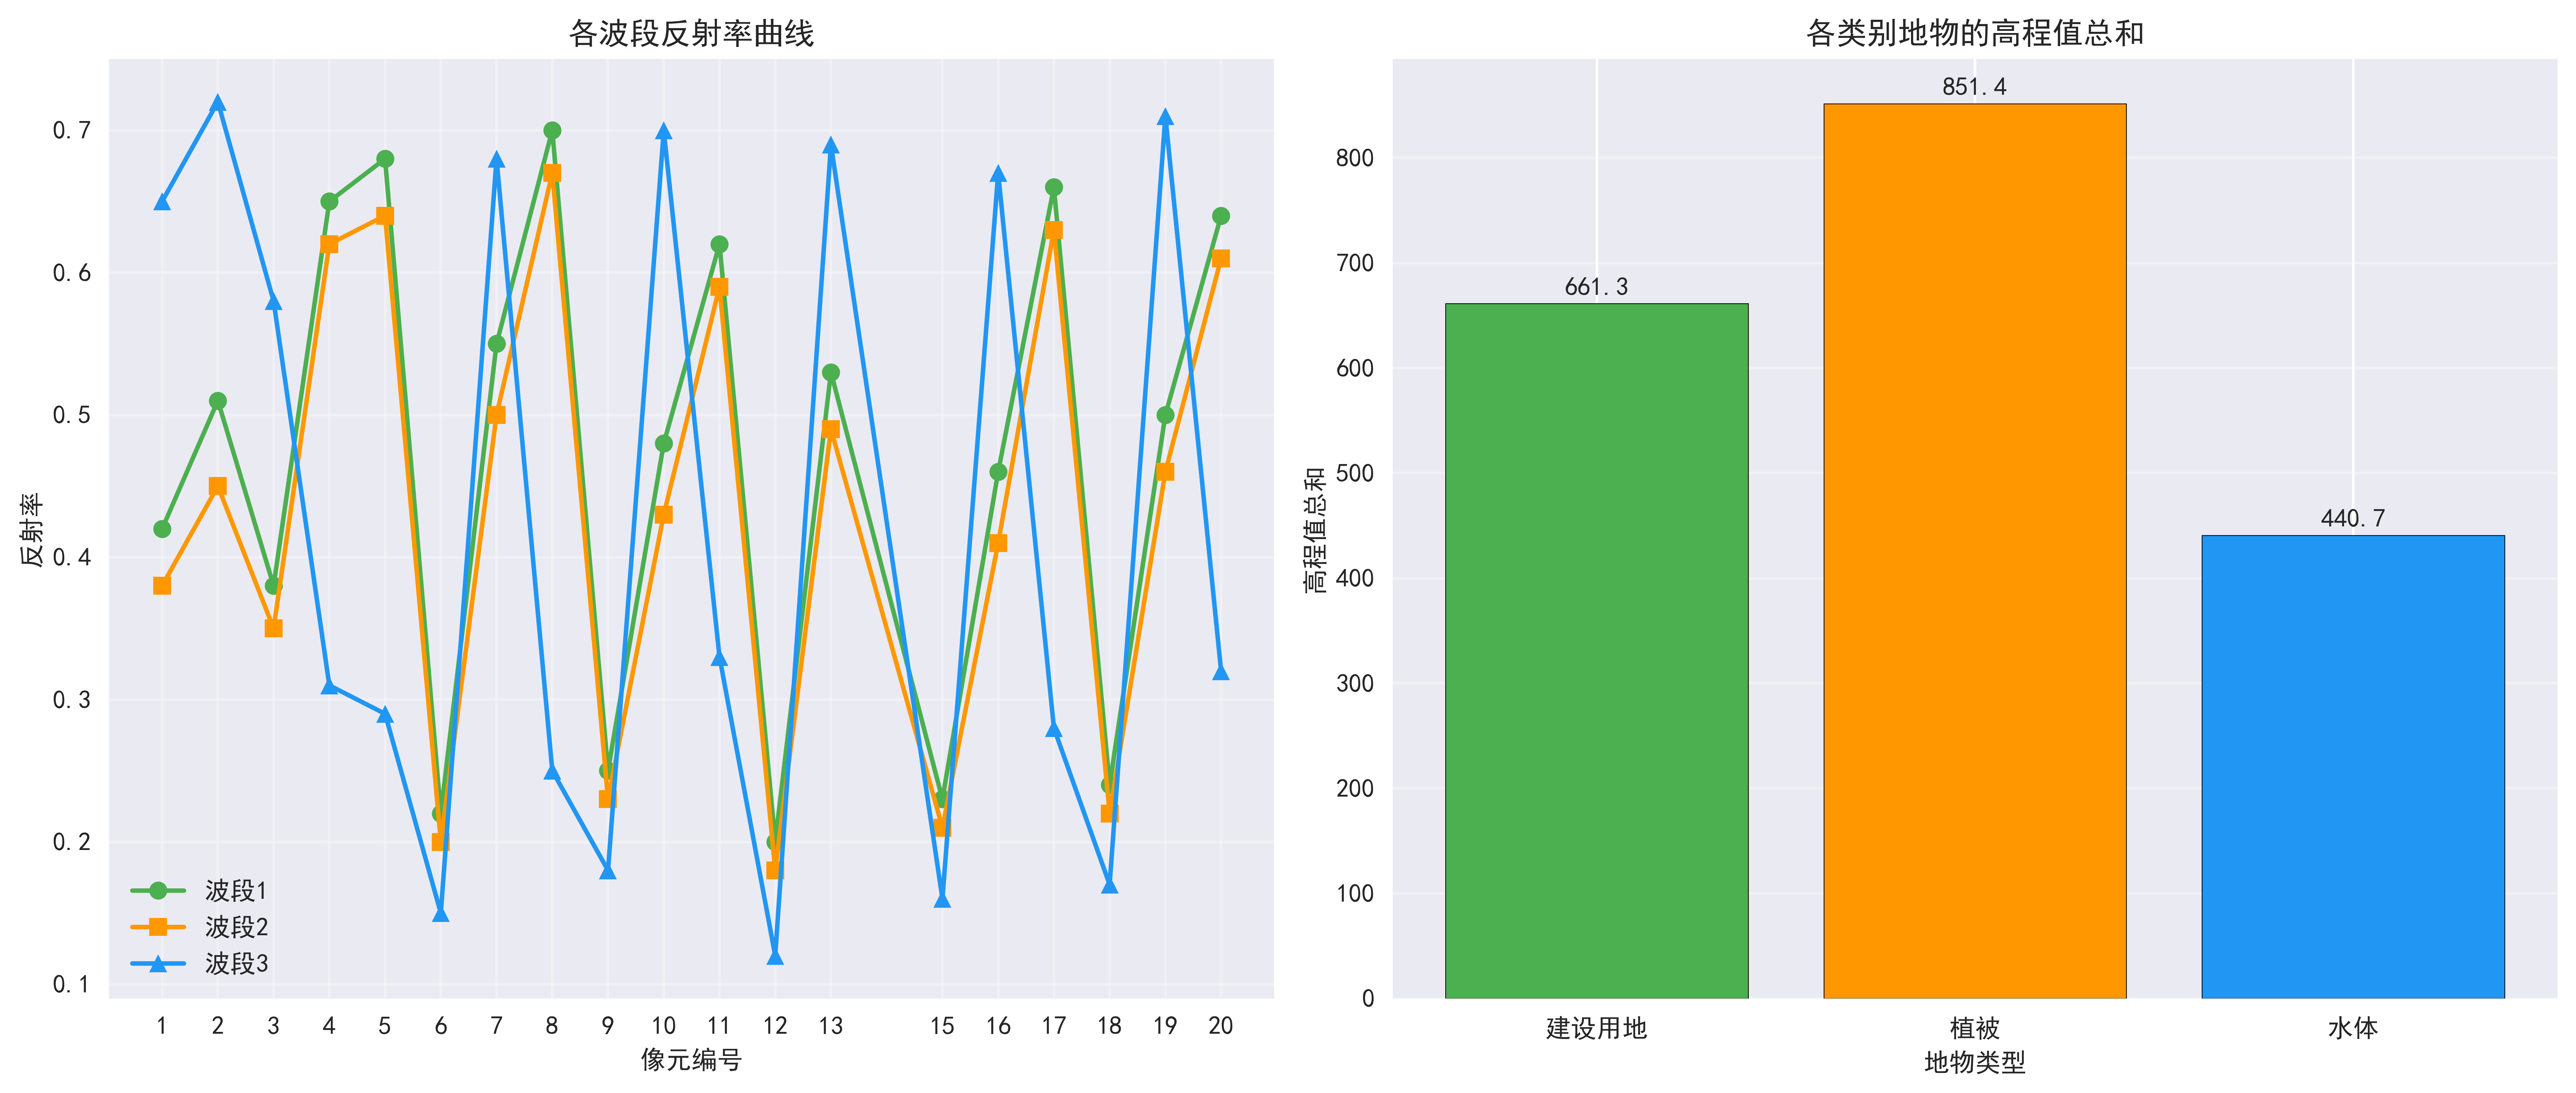

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# 配置中文字体，解决matplotlib中文显示问题
rcParams["font.family"] = ["SimHei"]
rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 读取 CSV 文件
df = pd.read_csv('testdata.csv')  # Replace with your file path

# 新建视图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------
# 1. 绘制反射率折线图
# --------------------------

# 提取反射率数据（波段1-3）和像元编号
reflectance_cols = ['波段1反射率', '波段2反射率', '波段3反射率']  # Keep original column names for data extraction
valid_data = df.dropna(subset=reflectance_cols)

band1 = valid_data['波段1反射率'].values
band2 = valid_data['波段2反射率'].values
band3 = valid_data['波段3反射率'].values
pixel_ids = valid_data['像元编号'].values

# 子图1：反射率折线图
ax1.plot(pixel_ids, band1, marker='o', label='波段1', color='#4CAF50')
ax1.plot(pixel_ids, band2, marker='s', label='波段2', color='#FF9800')
ax1.plot(pixel_ids, band3, marker='^', label='波段3', color='#2196F3')

ax1.set_title('各波段反射率曲线', fontsize=12)
ax1.set_xlabel('像元编号', fontsize=10)
ax1.set_ylabel('反射率', fontsize=10)
ax1.set_xticks(pixel_ids)
ax1.legend()
ax1.grid(alpha=0.3)

# --------------------------
# 2. 统计各类别高程值总和并绘制直方图
# --------------------------
elevation_sum = df.groupby('地物类型')['高程'].sum().reset_index()

elevation_sum['地物类型'] = elevation_sum['地物类型']

# 子图2：高程总和直方图
bars = ax2.bar(
    elevation_sum['地物类型'],
    elevation_sum['高程'],
    color=['#4CAF50', '#FF9800', '#2196F3'],
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2.,
        height + 5,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

ax2.set_title('各类别地物的高程值总和', fontsize=12)
ax2.set_xlabel('地物类型', fontsize=10)
ax2.set_ylabel('高程值总和', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()